<a href="https://colab.research.google.com/github/Manav716/Fraud_Detection_System/blob/main/Fraud_detection_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Fraud Detection — Premium EDA
**Dataset:** Credit Card Fraud Detection (Kaggle / ULB)  
**Rows:** 284,807 transactions | **Features:** 30 (V1–V28 are PCA-transformed) + Amount + Time  



# 1. Setup & Imports

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
import time
import pickle
warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   12,
})

FRAUD_COLOR  = '#e74c3c'   # red  — fraud
NORMAL_COLOR = '#2ecc71'   # green — normal
ACCENT_COLOR = '#3498db'   # blue — neutral accent

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


# 2. Load Data

In [136]:
df = pd.read_csv('/content/creditcard.csv')
df_raw = df.copy()

In [137]:
print('Dataset Shape:',df.shape)
print('Total Records:',df.shape[0])
print('Total Features:',df.shape[1])

Dataset Shape: (284807, 31)
Total Records: 284807
Total Features: 31


# 3. Basic Data Audits

In [138]:
# ── Data types and memory usage ───────────────────────────────────────────
print('='*55)
print('  DATA TYPES & MEMORY')
print('='*55)
print(df.dtypes)
print(f'\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

  DATA TYPES & MEMORY
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Memory usage: 70.6 MB


In [139]:
# ── Missing values — heatmap + summary ───────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('✅ No missing values found in any column — dataset is complete.')
else:
    print(missing_df)
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='Reds', ax=ax)
    ax.set_title('Missing Value Heatmap')
    plt.tight_layout()
    plt.show()

✅ No missing values found in any column — dataset is complete.


In [140]:
# ── Descriptive statistics — separated for readability ────────────────────
print('DESCRIPTIVE STATISTICS')
print('─'*60)
print('\n[ Time & Amount — interpretable features ]')
display(df[['Time', 'Amount', 'Class']].describe().T)

print('\n[ PCA features V1–V14 ]')
display(df[['V1','V2','V3','V4','V5','V6','V7',
            'V8','V9','V10','V11','V12','V13','V14']].describe().T.round(3))

print('\n[ PCA features V15–V28 ]')
display(df[['V15','V16','V17','V18','V19','V20','V21',
            'V22','V23','V24','V25','V26','V27','V28']].describe().T.round(3))

DESCRIPTIVE STATISTICS
────────────────────────────────────────────────────────────

[ Time & Amount — interpretable features ]


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16
Class,284807.0,0.001727,0.041527,0.0,0.0,0.0,0.000,1.00



[ PCA features V1–V14 ]


,count,mean,std,min,25%,50%,75%,max
V1,284807.0,0.0,1.959,-56.408,-0.920,0.018,1.316,2.455
V2,284807.0,0.0,1.651,-72.716,-0.599,0.065,0.804,22.058
V3,284807.0,-0.0,1.516,-48.326,-0.890,0.180,1.027,9.383
V4,284807.0,0.0,1.416,-5.683,-0.849,-0.020,0.743,16.875
V5,284807.0,0.0,1.380,-113.743,-0.692,-0.054,0.612,34.802
V6,284807.0,0.0,1.332,-26.161,-0.768,-0.274,0.399,73.302
V7,284807.0,-0.0,1.237,-43.557,-0.554,0.040,0.570,120.589
V8,284807.0,0.0,1.194,-73.217,-0.209,0.022,0.327,20.007
V9,284807.0,-0.0,1.099,-13.434,-0.643,-0.051,0.597,15.595
V10,284807.0,0.0,1.089,-24.588,-0.535,-0.093,0.454,23.745



[ PCA features V15–V28 ]


,count,mean,std,min,25%,50%,75%,max
V15,284807.0,0.0,0.915,-4.499,-0.583,0.048,0.649,8.878
V16,284807.0,0.0,0.876,-14.130,-0.468,0.066,0.523,17.315
V17,284807.0,-0.0,0.849,-25.163,-0.484,-0.066,0.400,9.254
V18,284807.0,0.0,0.838,-9.499,-0.499,-0.004,0.501,5.041
V19,284807.0,0.0,0.814,-7.214,-0.456,0.004,0.459,5.592
V20,284807.0,0.0,0.771,-54.498,-0.212,-0.062,0.133,39.421
V21,284807.0,0.0,0.735,-34.830,-0.228,-0.029,0.186,27.203
V22,284807.0,-0.0,0.726,-10.933,-0.542,0.007,0.529,10.503
V23,284807.0,0.0,0.624,-44.808,-0.162,-0.011,0.148,22.528
V24,284807.0,0.0,0.606,-2.837,-0.355,0.041,0.440,4.585


# 4. Duplicate Detection and Handling

In [141]:
# ── Duplicate analysis ────────────────────────────────────────────────────
n_dupes = df.duplicated().sum()
dupe_rows = df[df.duplicated(keep=False)]
dupe_rows

print(f'Total duplicate rows    : {n_dupes:,}')
print(f'As % of dataset         : {n_dupes/len(df)*100:.3f}%')
print(f'\nClass distribution in duplicates:')
print(dupe_rows['Class'].value_counts().rename({0:'Normal', 1:'Fraud'}))

print(f'\nFraud rows that are duplicates: {dupe_rows[dupe_rows["Class"]==1].shape[0]}')
print('NOTE: 19 fraud duplicates — do NOT drop blindly. Inspect first.')

# Show a sample of duplicate fraud rows for inspection
print('\nSample duplicate FRAUD rows:')
display(dupe_rows[dupe_rows['Class']==1][['Time','Amount','Class']].head(6))

Total duplicate rows    : 1,081
As % of dataset         : 0.380%

Class distribution in duplicates:
Class
Normal    1822
Fraud       32
Name: count, dtype: int64

Fraud rows that are duplicates: 32
NOTE: 19 fraud duplicates — do NOT drop blindly. Inspect first.

Sample duplicate FRAUD rows:


,Time,Amount,Class
102441,68207.0,1.0,1
102442,68207.0,1.0,1
102443,68207.0,1.0,1
102444,68207.0,1.0,1
102445,68207.0,1.0,1
102446,68207.0,1.0,1


In [142]:
# ── Decision: drop duplicates, keep first occurrence ─────────────────────
# Fraud duplicates may be genuine repeated transactions. However for modelling
# identical rows add no information and can bias evaluation.

df_clean = df.drop_duplicates(keep='first').reset_index(drop=True)

print(f'Original shape : {df.shape}')
print(f'After dedup    : {df_clean.shape}')
print(f'Rows removed   : {len(df) - len(df_clean):,}')
print(f'\nClass distribution after dedup:')
print(df_clean['Class'].value_counts().rename({0:'Normal', 1:'Fraud'}))

# Use df_clean going forward
df = df_clean.copy()
print('\n✅ df now points to de-duplicated dataset')

Original shape : (284807, 31)
After dedup    : (283726, 31)
Rows removed   : 1,081

Class distribution after dedup:
Class
Normal    283253
Fraud        473
Name: count, dtype: int64

✅ df now points to de-duplicated dataset


# 5. Class Imbalance Analysis

In [143]:
# ── Class distribution stats ──────────────────────────────────────────────
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print('='*40)
print(f'  Normal transactions : {class_counts[0]:>7,}  ({class_pct[0]:.3f}%)')
print(f'  Fraud  transactions : {class_counts[1]:>7,}  ({class_pct[1]:.3f}%)')
print(f'  Imbalance ratio     : {class_counts[0]/class_counts[1]:.0f}:1')
print('='*40)
print()
print('⚠️  This is SEVERE imbalance.')
print('   A model predicting "not fraud" always → 99.8% accuracy but 0% recall.')
print('   We MUST use Precision-Recall AUC, not accuracy, to evaluate.')

  Normal transactions : 283,253  (99.833%)
  Fraud  transactions :     473  (0.167%)
  Imbalance ratio     : 599:1

⚠️  This is SEVERE imbalance.
   A model predicting "not fraud" always → 99.8% accuracy but 0% recall.
   We MUST use Precision-Recall AUC, not accuracy, to evaluate.


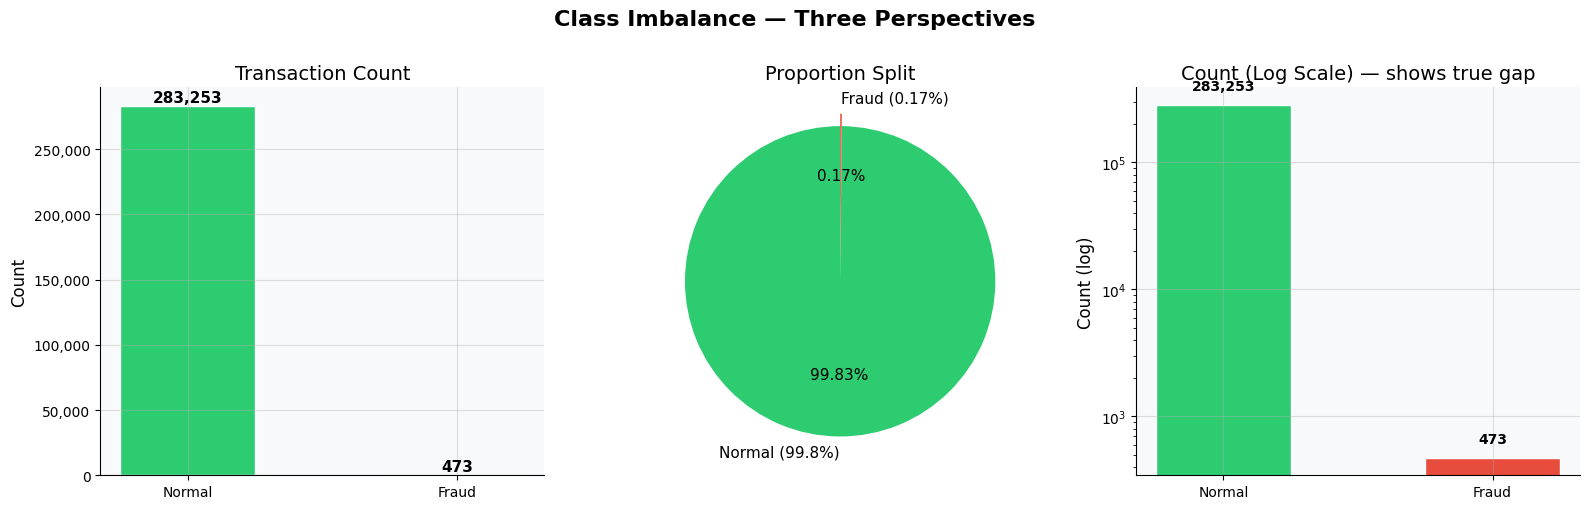

In [144]:
# ── Class imbalance visualization ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Class Imbalance — Three Perspectives', fontsize=16, fontweight='bold', y=1.01)

# Bar chart
bars = axes[0].bar(['Normal', 'Fraud'], class_counts.values,
                   color=[NORMAL_COLOR, FRAUD_COLOR], edgecolor='white', width=0.5)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Transaction Count')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
axes[1].pie(class_counts.values, labels=['Normal (99.8%)', 'Fraud (0.17%)'],
            colors=[NORMAL_COLOR, FRAUD_COLOR], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.08), textprops={'fontsize': 11})
axes[1].set_title('Proportion Split')

# Log-scale bar to show the true scale difference
axes[2].bar(['Normal', 'Fraud'], class_counts.values,
            color=[NORMAL_COLOR, FRAUD_COLOR], edgecolor='white', width=0.5)
axes[2].set_yscale('log')
axes[2].set_title('Count (Log Scale) — shows true gap')
axes[2].set_ylabel('Count (log)')
for bar, val in zip(axes[2].patches, class_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.3,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Amount Analysis - Normal v/s Fraud

In [145]:
# ── Amount statistics: Normal vs Fraud ───────────────────────────────────
fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print('AMOUNT STATISTICS — Normal vs Fraud')
print('─'*50)
amount_comp = pd.DataFrame({
    'Normal':  normal['Amount'].describe(),
    'Fraud' :  fraud['Amount'].describe()
}).round(2)
display(amount_comp)

print(f'\n💡 Key insight:')
print(f'   Fraud median amount : ₹{fraud["Amount"].median():.2f}')
print(f'   Normal median amount: ₹{normal["Amount"].median():.2f}')
print(f'   Max fraud amount    : ₹{fraud["Amount"].max():,.2f}')
print(f'   Max normal amount   : ₹{normal["Amount"].max():,.2f}')
print(f'\n   Many frauds happen at SMALL amounts — fraudsters test cards with small txns.')

AMOUNT STATISTICS — Normal vs Fraud
──────────────────────────────────────────────────


,Normal,Fraud
count,283253.00,473.00
mean,88.41,123.87
std,250.38,260.21
min,0.00,0.00
25%,5.67,1.00
50%,22.00,9.82
75%,77.46,105.89
max,25691.16,2125.87



💡 Key insight:
   Fraud median amount : ₹9.82
   Normal median amount: ₹22.00
   Max fraud amount    : ₹2,125.87
   Max normal amount   : ₹25,691.16

   Many frauds happen at SMALL amounts — fraudsters test cards with small txns.


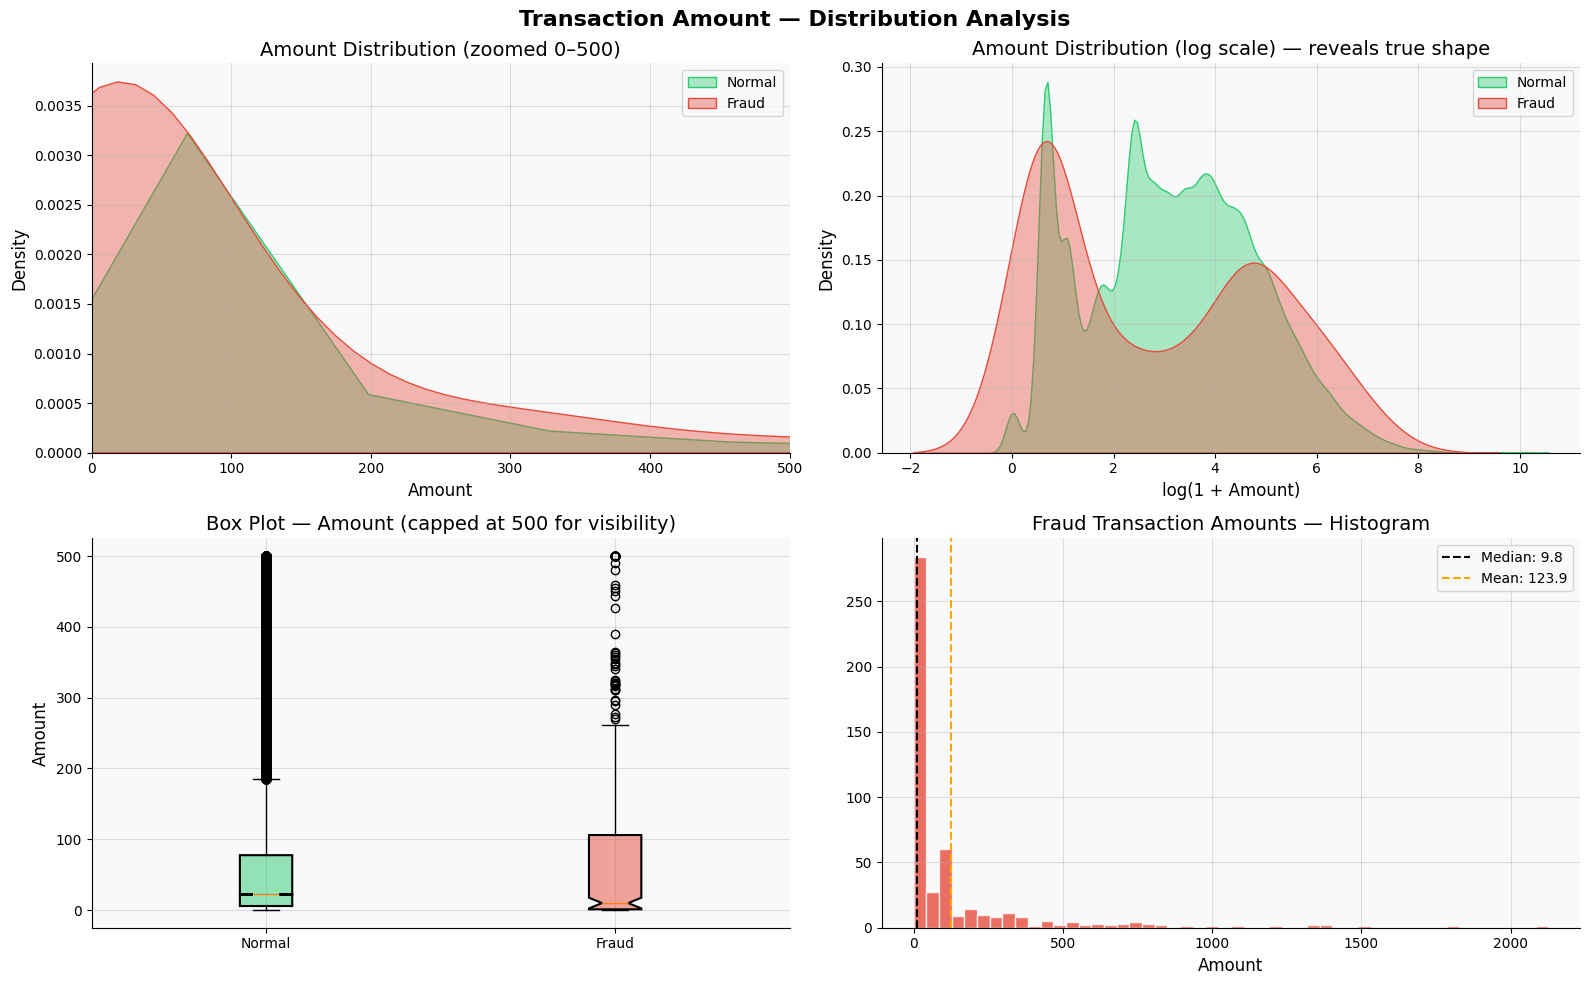

In [146]:
# ── Amount distribution plots ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Transaction Amount — Distribution Analysis', fontsize=16, fontweight='bold')

# 1. KDE — Amount distribution by class
sns.kdeplot(normal['Amount'], ax=axes[0,0], color=NORMAL_COLOR, label='Normal', fill=True, alpha=0.4)
sns.kdeplot(fraud['Amount'],  ax=axes[0,0], color=FRAUD_COLOR,  label='Fraud',  fill=True, alpha=0.4)
axes[0,0].set_xlim(0, 500)
axes[0,0].set_title('Amount Distribution (zoomed 0–500)')
axes[0,0].set_xlabel('Amount')
axes[0,0].legend()

# 2. Log-scale amount distribution
log_normal = np.log1p(normal['Amount'])
log_fraud  = np.log1p(fraud['Amount'])
sns.kdeplot(log_normal, ax=axes[0,1], color=NORMAL_COLOR, label='Normal', fill=True, alpha=0.4)
sns.kdeplot(log_fraud,  ax=axes[0,1], color=FRAUD_COLOR,  label='Fraud',  fill=True, alpha=0.4)
axes[0,1].set_title('Amount Distribution (log scale) — reveals true shape')
axes[0,1].set_xlabel('log(1 + Amount)')
axes[0,1].legend()

# 3. Box plot
amount_data = [normal['Amount'].clip(upper=500), fraud['Amount'].clip(upper=500)]
bp = axes[1,0].boxplot(amount_data, labels=['Normal', 'Fraud'],
                        patch_artist=True, notch=True,
                        boxprops=dict(linewidth=1.5))
bp['boxes'][0].set_facecolor(NORMAL_COLOR + '80')
bp['boxes'][1].set_facecolor(FRAUD_COLOR  + '80')
axes[1,0].set_title('Box Plot — Amount (capped at 500 for visibility)')
axes[1,0].set_ylabel('Amount')

# 4. Fraud amount histogram — small amounts
axes[1,1].hist(fraud['Amount'], bins=50, color=FRAUD_COLOR, edgecolor='white', alpha=0.8)
axes[1,1].axvline(fraud['Amount'].median(), color='black', linestyle='--',
                  label=f'Median: {fraud["Amount"].median():.1f}')
axes[1,1].axvline(fraud['Amount'].mean(),   color='orange', linestyle='--',
                  label=f'Mean: {fraud["Amount"].mean():.1f}')
axes[1,1].set_title('Fraud Transaction Amounts — Histogram')
axes[1,1].set_xlabel('Amount')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# 7. Time Analysis - Transaction Pattern

Dataset spans 2 days (~48 hours) of transactions.
Time range: 0s to 172792s
Hour range: 0 to 48 hours (wraps around midnight)


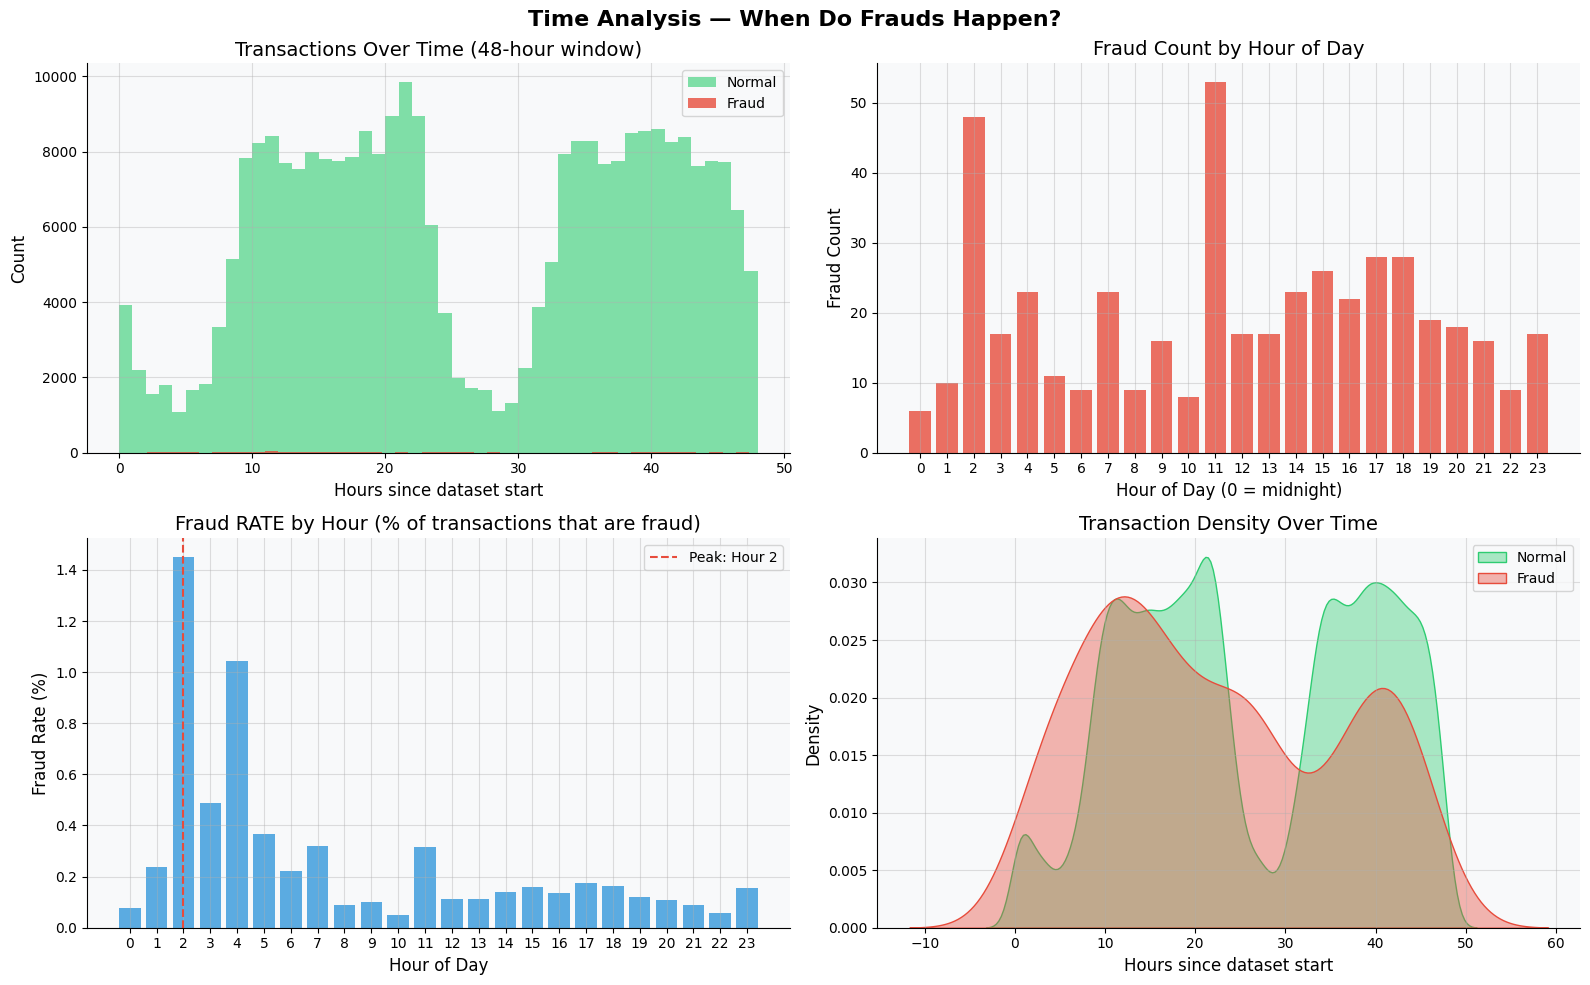


💡 Peak fraud rate hour: 2:00 (1.45% of transactions are fraud)
   Fraud is proportionally higher during low-volume hours (night) —
   fewer legitimate transactions means fraudulent ones stand out less.


In [147]:
# ── Convert Time (seconds) to hour-of-day ────────────────────────────────
df['Hour'] = (df['Time'] / 3600).astype(int) % 24
fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print('Dataset spans 2 days (~48 hours) of transactions.')
print(f'Time range: {df["Time"].min():.0f}s to {df["Time"].max():.0f}s')
print(f'Hour range: 0 to {(df["Time"].max()/3600):.0f} hours (wraps around midnight)')

# ── Time plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Time Analysis — When Do Frauds Happen?', fontsize=16, fontweight='bold')

# 1. Transaction volume over raw time
axes[0,0].hist(normal['Time']/3600, bins=48, alpha=0.6, color=NORMAL_COLOR, label='Normal')
axes[0,0].hist(fraud['Time']/3600,  bins=48, alpha=0.8, color=FRAUD_COLOR,  label='Fraud')
axes[0,0].set_title('Transactions Over Time (48-hour window)')
axes[0,0].set_xlabel('Hours since dataset start')
axes[0,0].set_ylabel('Count')
axes[0,0].legend()

# 2. Fraud by hour of day
fraud_by_hour  = fraud.groupby('Hour').size()
normal_by_hour = normal.groupby('Hour').size()
hours = range(24)
axes[0,1].bar(hours, [fraud_by_hour.get(h, 0) for h in hours],
              color=FRAUD_COLOR, alpha=0.8, label='Fraud')
axes[0,1].set_title('Fraud Count by Hour of Day')
axes[0,1].set_xlabel('Hour of Day (0 = midnight)')
axes[0,1].set_ylabel('Fraud Count')
axes[0,1].set_xticks(range(24))

# 3. Fraud rate by hour (fraud / total transactions that hour)
fraud_rate_by_hour = {}
for h in range(24):
    total = len(df[df['Hour'] == h])
    f     = len(fraud[fraud['Hour'] == h])
    fraud_rate_by_hour[h] = (f / total * 100) if total > 0 else 0

axes[1,0].bar(fraud_rate_by_hour.keys(), fraud_rate_by_hour.values(),
              color=ACCENT_COLOR, alpha=0.8)
axes[1,0].set_title('Fraud RATE by Hour (% of transactions that are fraud)')
axes[1,0].set_xlabel('Hour of Day')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].set_xticks(range(24))
peak_hour = max(fraud_rate_by_hour, key=fraud_rate_by_hour.get)
axes[1,0].axvline(peak_hour, color=FRAUD_COLOR, linestyle='--',
                  label=f'Peak: Hour {peak_hour}')
axes[1,0].legend()

# 4. KDE of time for both classes
sns.kdeplot(normal['Time']/3600, ax=axes[1,1], color=NORMAL_COLOR,
            fill=True, alpha=0.4, label='Normal')
sns.kdeplot(fraud['Time']/3600,  ax=axes[1,1], color=FRAUD_COLOR,
            fill=True, alpha=0.4, label='Fraud')
axes[1,1].set_title('Transaction Density Over Time')
axes[1,1].set_xlabel('Hours since dataset start')
axes[1,1].legend()

plt.tight_layout()
plt.show()

print(f'\n💡 Peak fraud rate hour: {peak_hour}:00 ({fraud_rate_by_hour[peak_hour]:.2f}% of transactions are fraud)')
print('   Fraud is proportionally higher during low-volume hours (night) —')
print('   fewer legitimate transactions means fraudulent ones stand out less.')

# 8. Feature Distributions - V1 to V28(Normal v/s Fraud)

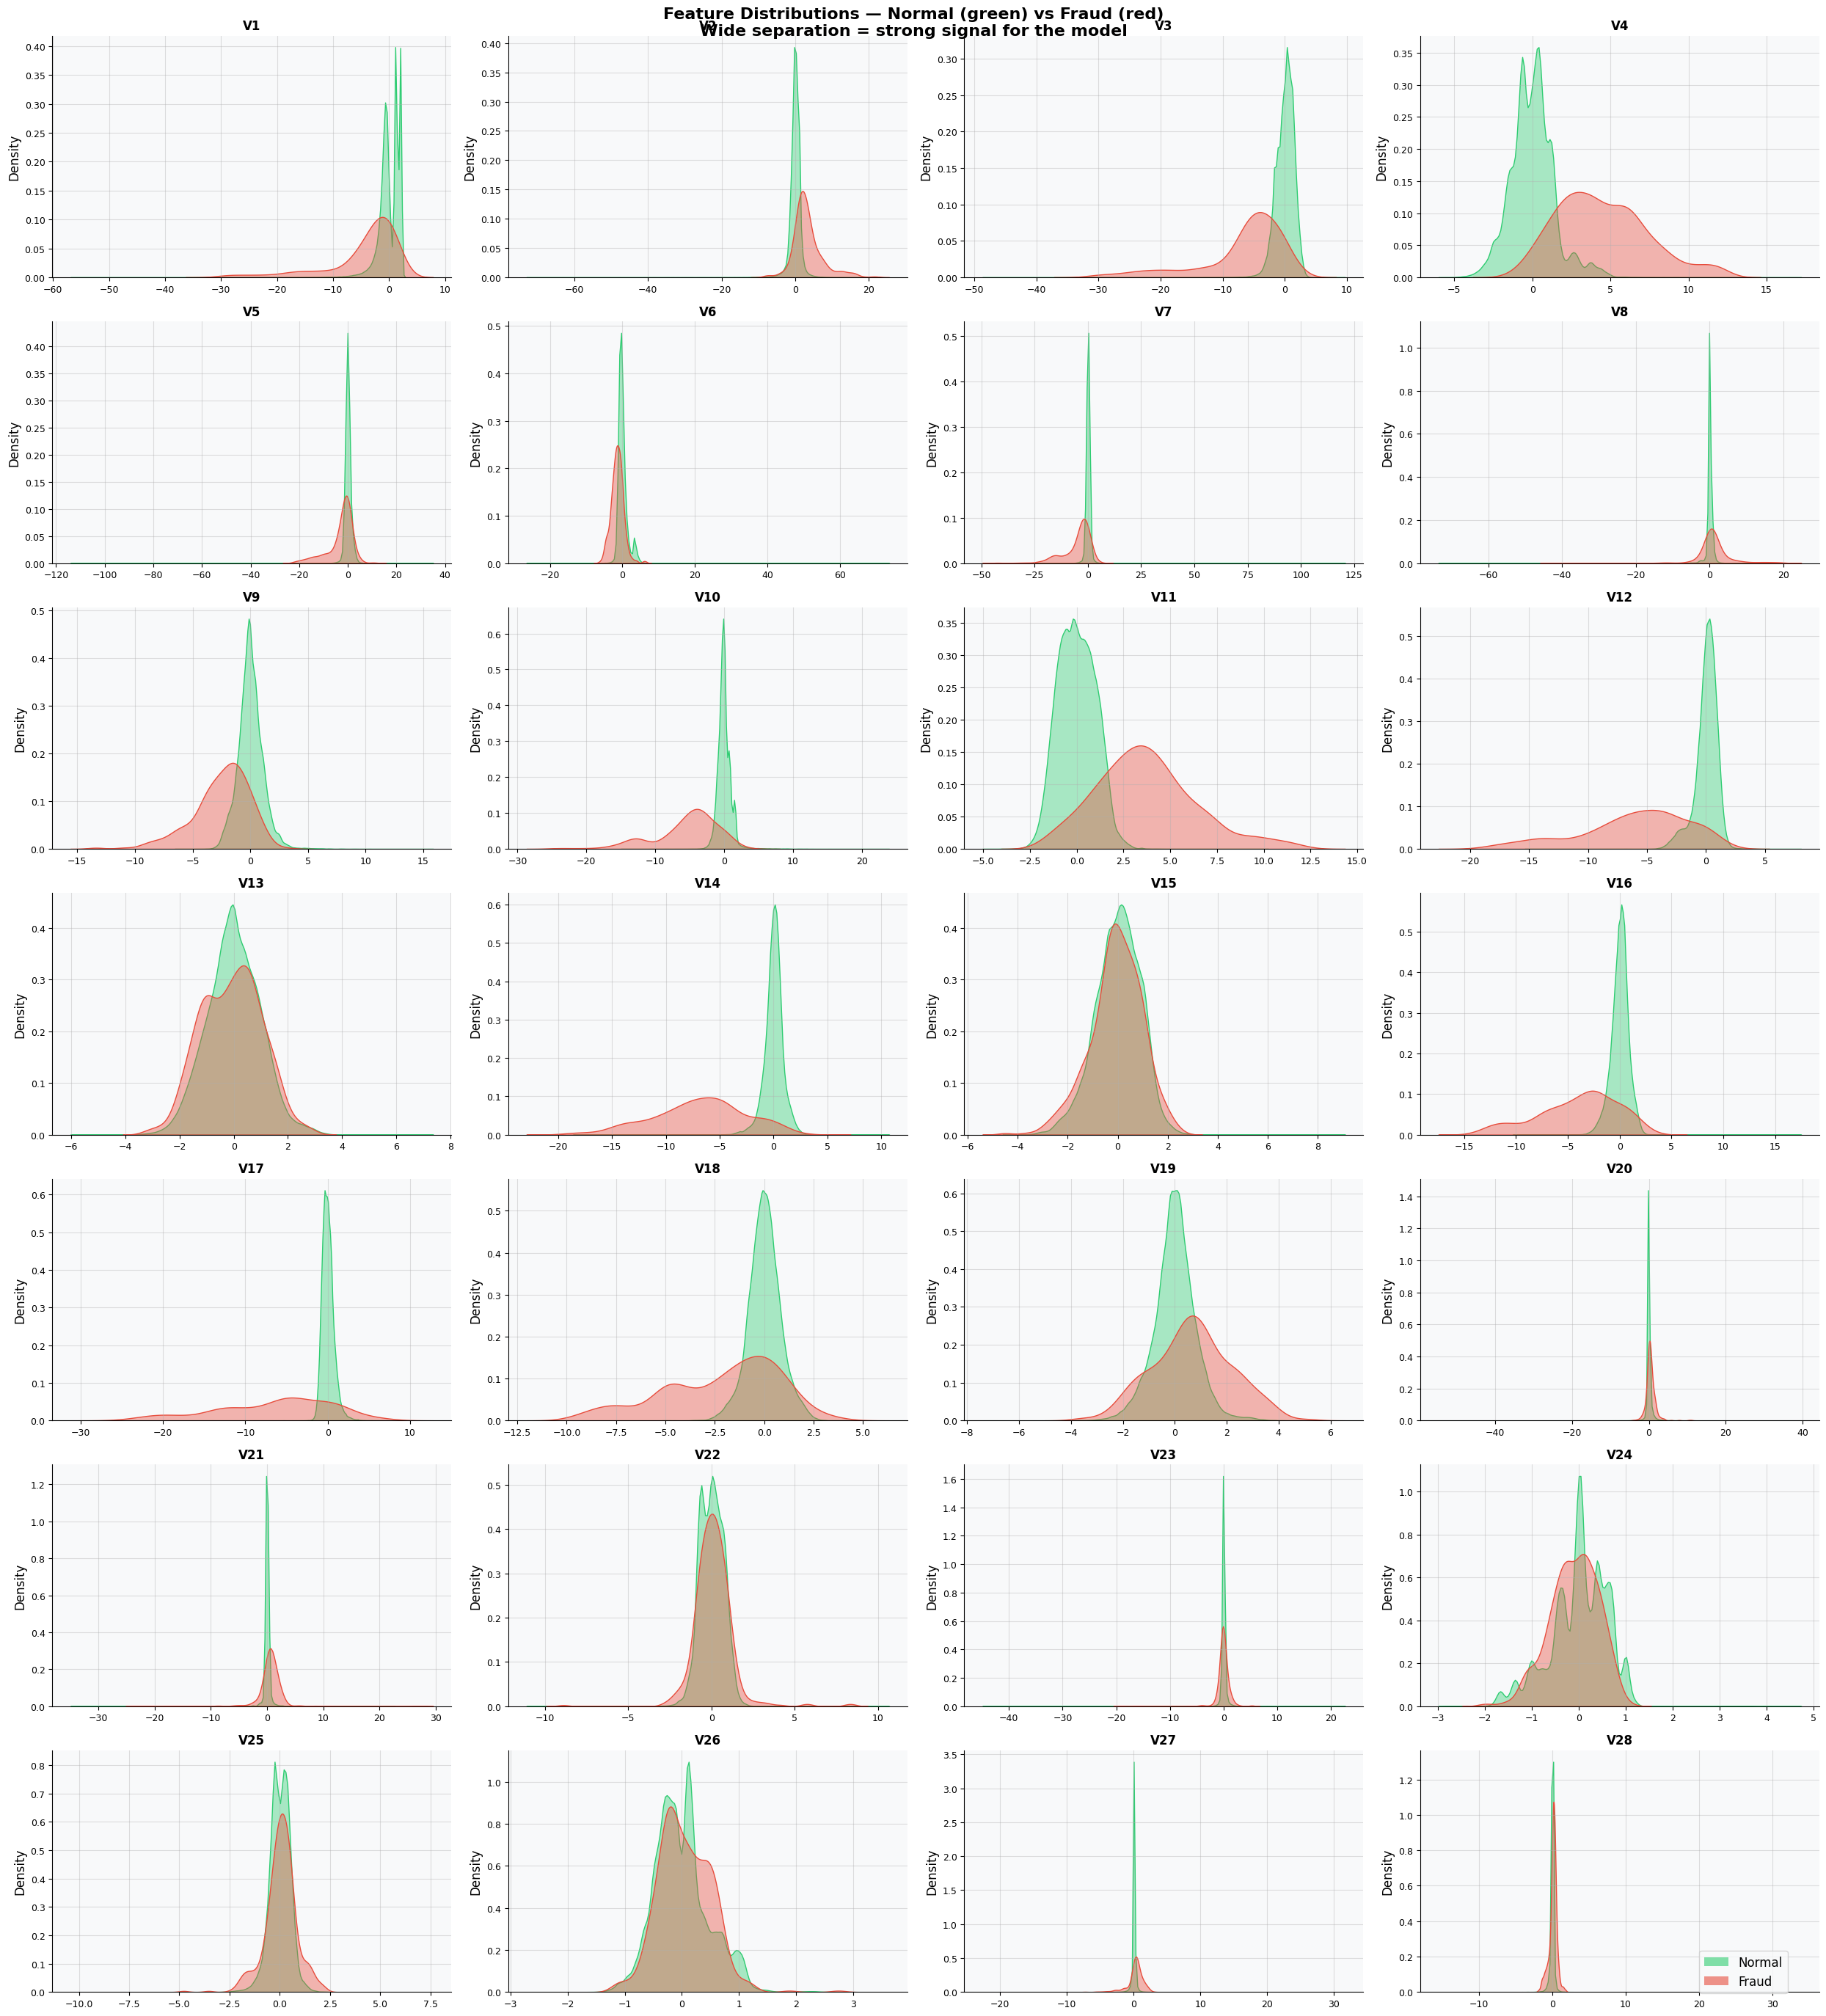

💡 Features with largest class separation (most useful):
   V17, V14, V12, V10, V16, V3 — these will be top model features.
   Features where curves overlap heavily (V13, V15, V25) = low signal.


In [148]:
# ── KDE plots for all V features — Normal vs Fraud ────────────────────────
# These are PCA components — we look for features where distributions DIFFER
# between classes. Different distributions = useful signal for the model.

v_features = [f'V{i}' for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(25, 28))
fig.suptitle('Feature Distributions — Normal (green) vs Fraud (red)\n'
             'Wide separation = strong signal for the model',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(v_features):
    sns.kdeplot(normal[feat], ax=axes[i], color=NORMAL_COLOR,
                fill=True, alpha=0.4, label='Normal')
    sns.kdeplot(fraud[feat],  ax=axes[i], color=FRAUD_COLOR,
                fill=True, alpha=0.4, label='Fraud')
    axes[i].set_title(f'{feat}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=9)

# Hide unused subplots (28 features, 28 slots — none unused here)
for j in range(len(v_features), len(axes)):
    axes[j].set_visible(False)

# Add a single shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=NORMAL_COLOR, alpha=0.6, label='Normal'),
                   Patch(facecolor=FRAUD_COLOR,  alpha=0.6, label='Fraud')]
fig.legend(handles=legend_elements, loc='lower right', fontsize=12,
           bbox_to_anchor=(0.98, 0.01))

plt.tight_layout()
plt.show()

print('💡 Features with largest class separation (most useful):')
print('   V17, V14, V12, V10, V16, V3 — these will be top model features.')
print('   Features where curves overlap heavily (V13, V15, V25) = low signal.')

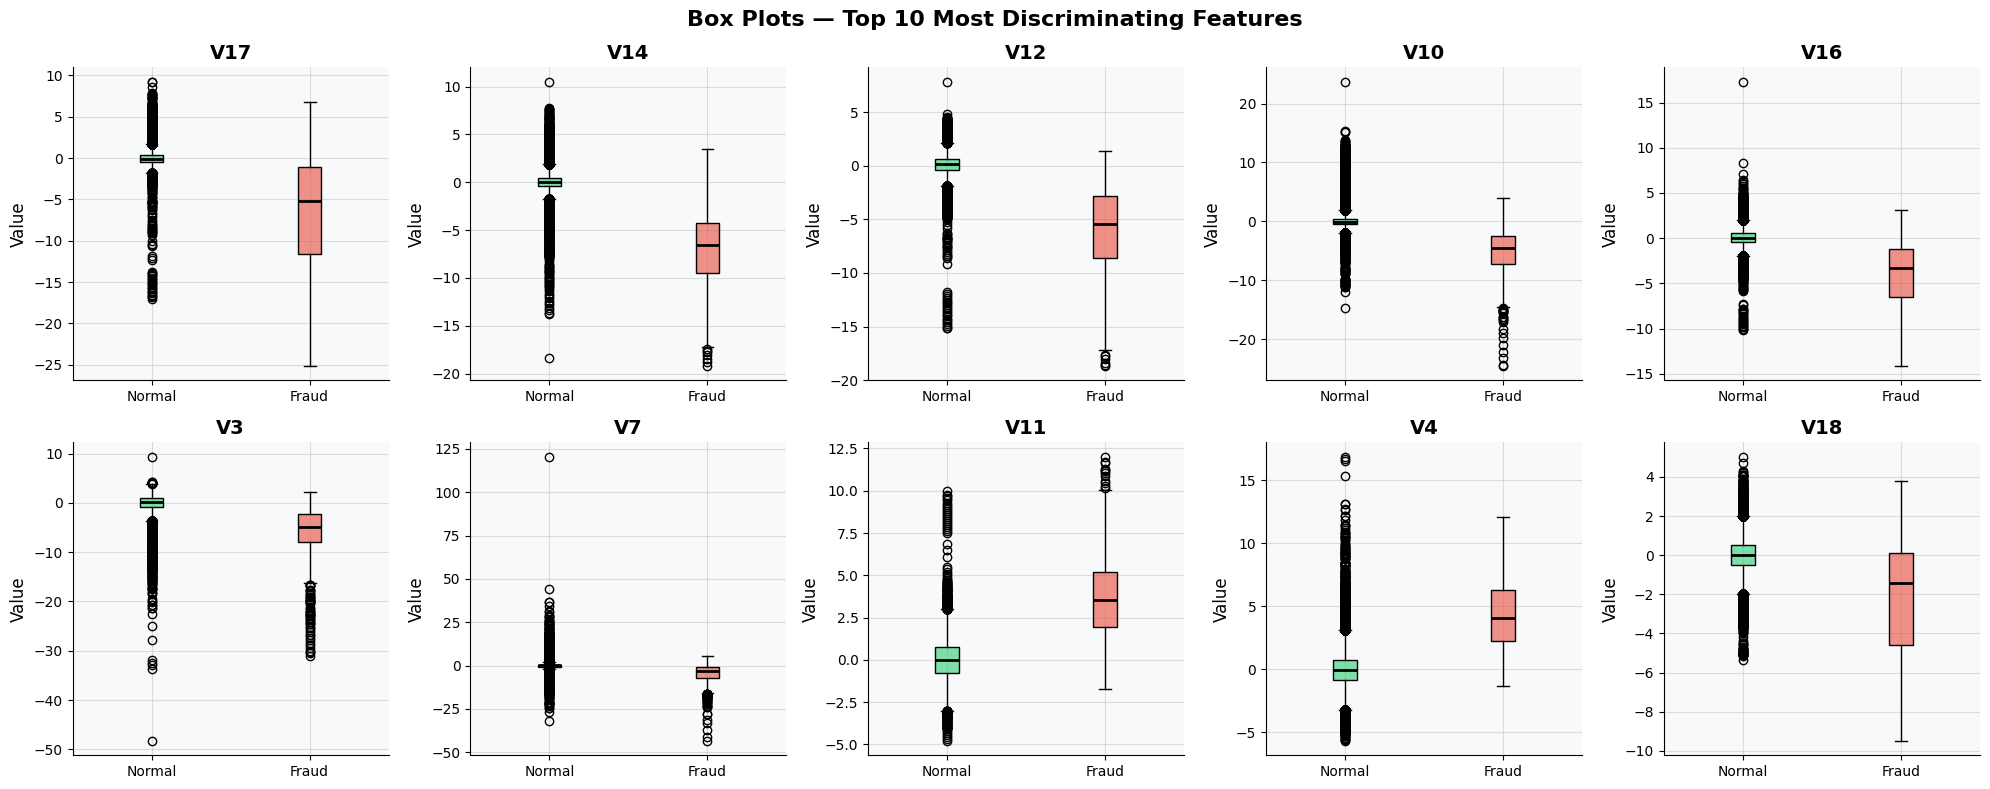

In [149]:
# ── Box plots for top correlated features ─────────────────────────────────
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Box Plots — Top 10 Most Discriminating Features',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data = [normal[feat], fraud[feat]]
    bp = axes[i].boxplot(data, labels=['Normal', 'Fraud'],
                          patch_artist=True, notch=False,
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor(NORMAL_COLOR + '99')
    bp['boxes'][1].set_facecolor(FRAUD_COLOR  + '99')
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

## 9. Outlier Detection

In [150]:
# ── Method 1: IQR method on Amount ───────────────────────────────────────
Q1  = df['Amount'].quantile(0.25)
Q3  = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print('IQR Outlier Detection — Amount')
print('─'*45)
print(f'Q1                 : {Q1:.2f}')
print(f'Q3                 : {Q3:.2f}')
print(f'IQR                : {IQR:.2f}')
print(f'Lower bound        : {lower_bound:.2f}')
print(f'Upper bound        : {upper_bound:.2f}')
print(f'Outlier count      : {len(outliers_iqr):,} ({len(outliers_iqr)/len(df)*100:.2f}%)')
print(f'\nClass breakdown of outliers:')
print(outliers_iqr['Class'].value_counts().rename({0:'Normal', 1:'Fraud'}))
print(f'\n⚠️  {outliers_iqr["Class"].sum()} fraud transactions are classified as outliers.')
print('   We will NOT remove outliers — they may be genuine fraud signals.')

IQR Outlier Detection — Amount
─────────────────────────────────────────────
Q1                 : 5.60
Q3                 : 77.51
IQR                : 71.91
Lower bound        : -102.27
Upper bound        : 185.38
Outlier count      : 31,685 (11.17%)

Class breakdown of outliers:
Class
Normal    31598
Fraud        87
Name: count, dtype: int64

⚠️  87 fraud transactions are classified as outliers.
   We will NOT remove outliers — they may be genuine fraud signals.


In [151]:
# ── Method 2: Z-score method ──────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df[['Amount', 'Time']]))
outliers_z = df[(z_scores > 3).any(axis=1)]

print('Z-score Outlier Detection (threshold = 3)')
print('─'*45)
print(f'Outlier count: {len(outliers_z):,} ({len(outliers_z)/len(df)*100:.2f}%)')
print(f'Class breakdown:')
print(outliers_z['Class'].value_counts().rename({0:'Normal', 1:'Fraud'}))

Z-score Outlier Detection (threshold = 3)
─────────────────────────────────────────────
Outlier count: 4,063 (1.43%)
Class breakdown:
Class
Normal    4052
Fraud       11
Name: count, dtype: int64


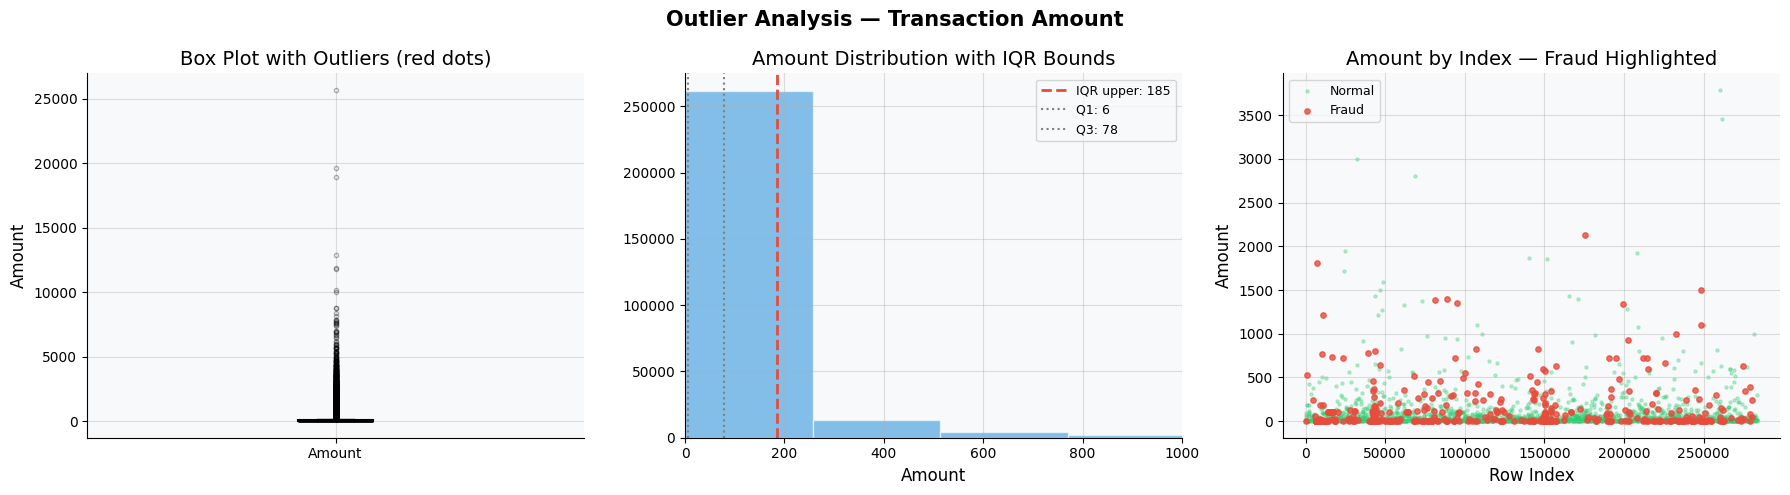


💡 Decision: Keep all outliers.
   Fraud itself IS an outlier in behaviour — removing outliers could
   remove genuine fraud signals. We handle them via log-transform instead.


In [152]:
# ── Outlier visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Outlier Analysis — Transaction Amount', fontsize=15, fontweight='bold')

# 1. Box plot with outlier overlay
axes[0].boxplot(df['Amount'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=ACCENT_COLOR+'55', linewidth=1.5),
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', color=FRAUD_COLOR, alpha=0.3, markersize=3))
axes[0].set_title('Box Plot with Outliers (red dots)')
axes[0].set_ylabel('Amount')
axes[0].set_xticklabels(['Amount'])

# 2. IQR bounds overlaid on distribution
axes[1].hist(df['Amount'], bins=100, color=ACCENT_COLOR, alpha=0.6, edgecolor='white')
axes[1].axvline(upper_bound, color=FRAUD_COLOR, linestyle='--', linewidth=2,
                label=f'IQR upper: {upper_bound:.0f}')
axes[1].axvline(Q1, color='gray', linestyle=':', linewidth=1.5, label=f'Q1: {Q1:.0f}')
axes[1].axvline(Q3, color='gray', linestyle=':', linewidth=1.5, label=f'Q3: {Q3:.0f}')
axes[1].set_xlim(0, 1000)
axes[1].set_title('Amount Distribution with IQR Bounds')
axes[1].set_xlabel('Amount')
axes[1].legend(fontsize=9)

# 3. Fraud vs Normal scatter on Amount
axes[2].scatter(normal.sample(2000, random_state=42).index,
                normal.sample(2000, random_state=42)['Amount'],
                color=NORMAL_COLOR, alpha=0.3, s=5, label='Normal')
axes[2].scatter(fraud.index, fraud['Amount'],
                color=FRAUD_COLOR, alpha=0.8, s=15, label='Fraud', zorder=5)
axes[2].set_title('Amount by Index — Fraud Highlighted')
axes[2].set_xlabel('Row Index')
axes[2].set_ylabel('Amount')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print()
print('💡 Decision: Keep all outliers.')
print('   Fraud itself IS an outlier in behaviour — removing outliers could')
print('   remove genuine fraud signals. We handle them via log-transform instead.')

In [153]:
# ── Outlier detection on V features (per class) ──────────────────────────
print('Outlier counts per V feature (Z-score > 3, per class):')
print('─'*50)
outlier_summary = {}
for feat in v_features:
    z_normal = np.abs(stats.zscore(normal[feat]))
    z_fraud  = np.abs(stats.zscore(fraud[feat]))
    outlier_summary[feat] = {
        'Normal outliers': (z_normal > 3).sum(),
        'Fraud outliers' : (z_fraud  > 3).sum()
    }

outlier_df = pd.DataFrame(outlier_summary).T
outlier_df['Fraud outlier %'] = (outlier_df['Fraud outliers'] / len(fraud) * 100).round(1)
print(outlier_df.sort_values('Fraud outlier %', ascending=False).head(10))

Outlier counts per V feature (Z-score > 3, per class):
──────────────────────────────────────────────────
     Normal outliers  Fraud outliers  Fraud outlier %
V1              3670              13              2.7
V8              4190              11              2.3
V21             4082              10              2.1
V27             4695              10              2.1
V2              4277               9              1.9
V3              1943               8              1.7
V5              2906               8              1.7
V7              3513               7              1.5
V23             3352               7              1.5
V20             4586               6              1.3


## 10. Correlation Analysis

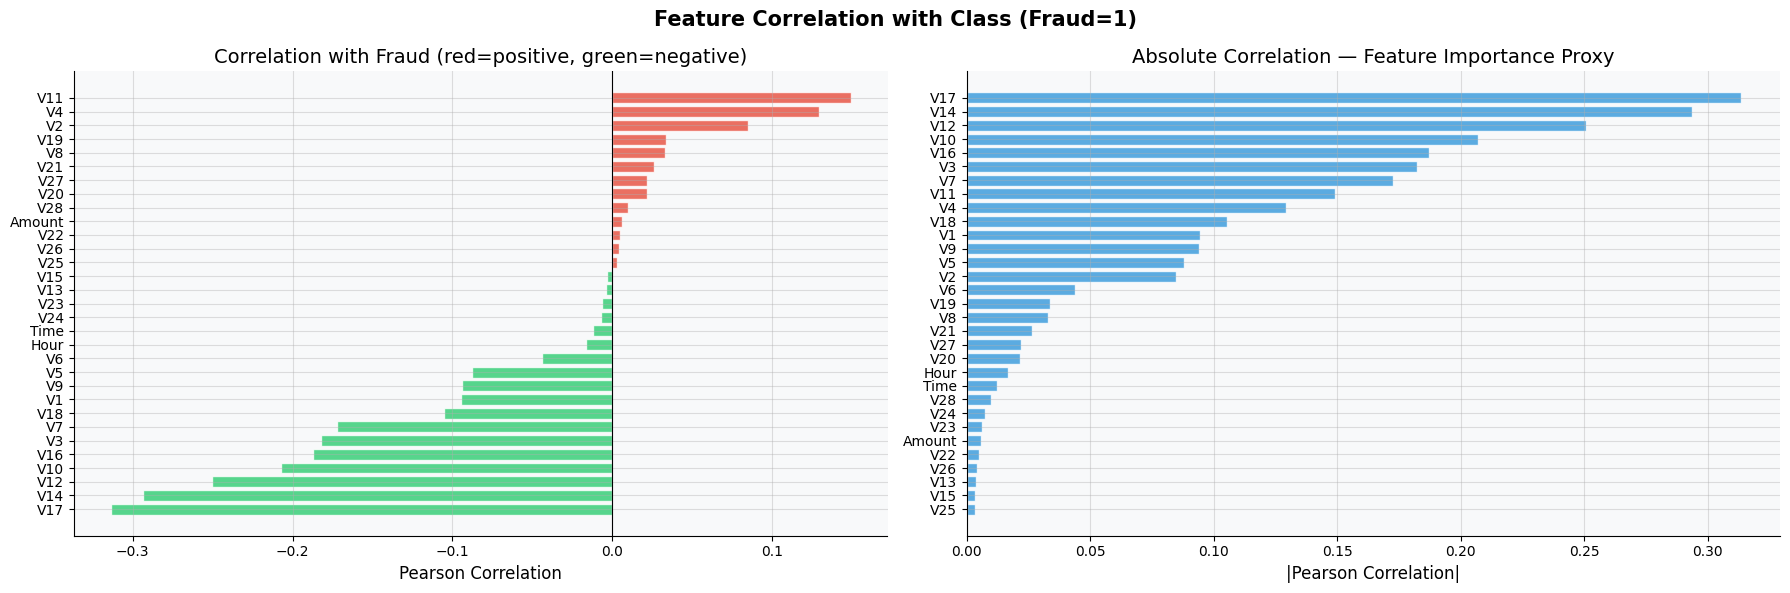

Top features positively correlated with fraud (fraud tends to be HIGHER):
V11    0.149067
V4     0.129326
V2     0.084624
V19    0.033631
V8     0.033068
Name: Class, dtype: float64

Top features negatively correlated with fraud (fraud tends to be LOWER):
V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
Name: Class, dtype: float64


In [154]:
# ── Correlation with Class (target) ──────────────────────────────────────
corr_with_class = df.corr()['Class'].drop('Class').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Feature Correlation with Class (Fraud=1)', fontsize=15, fontweight='bold')

# 1. Bar chart — correlation values
colors = [FRAUD_COLOR if v > 0 else NORMAL_COLOR for v in corr_with_class.values]
bars = axes[0].barh(corr_with_class.index, corr_with_class.values,
                    color=colors, edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Correlation with Fraud (red=positive, green=negative)')
axes[0].set_xlabel('Pearson Correlation')

# 2. Absolute correlation — sorted importance
abs_corr = corr_with_class.abs().sort_values(ascending=True)
axes[1].barh(abs_corr.index, abs_corr.values,
             color=ACCENT_COLOR, edgecolor='white', alpha=0.8)
axes[1].set_title('Absolute Correlation — Feature Importance Proxy')
axes[1].set_xlabel('|Pearson Correlation|')

plt.tight_layout()
plt.show()

print('Top features positively correlated with fraud (fraud tends to be HIGHER):')
print(corr_with_class.sort_values(ascending=False).head(5))
print('\nTop features negatively correlated with fraud (fraud tends to be LOWER):')
print(corr_with_class.sort_values().head(5))

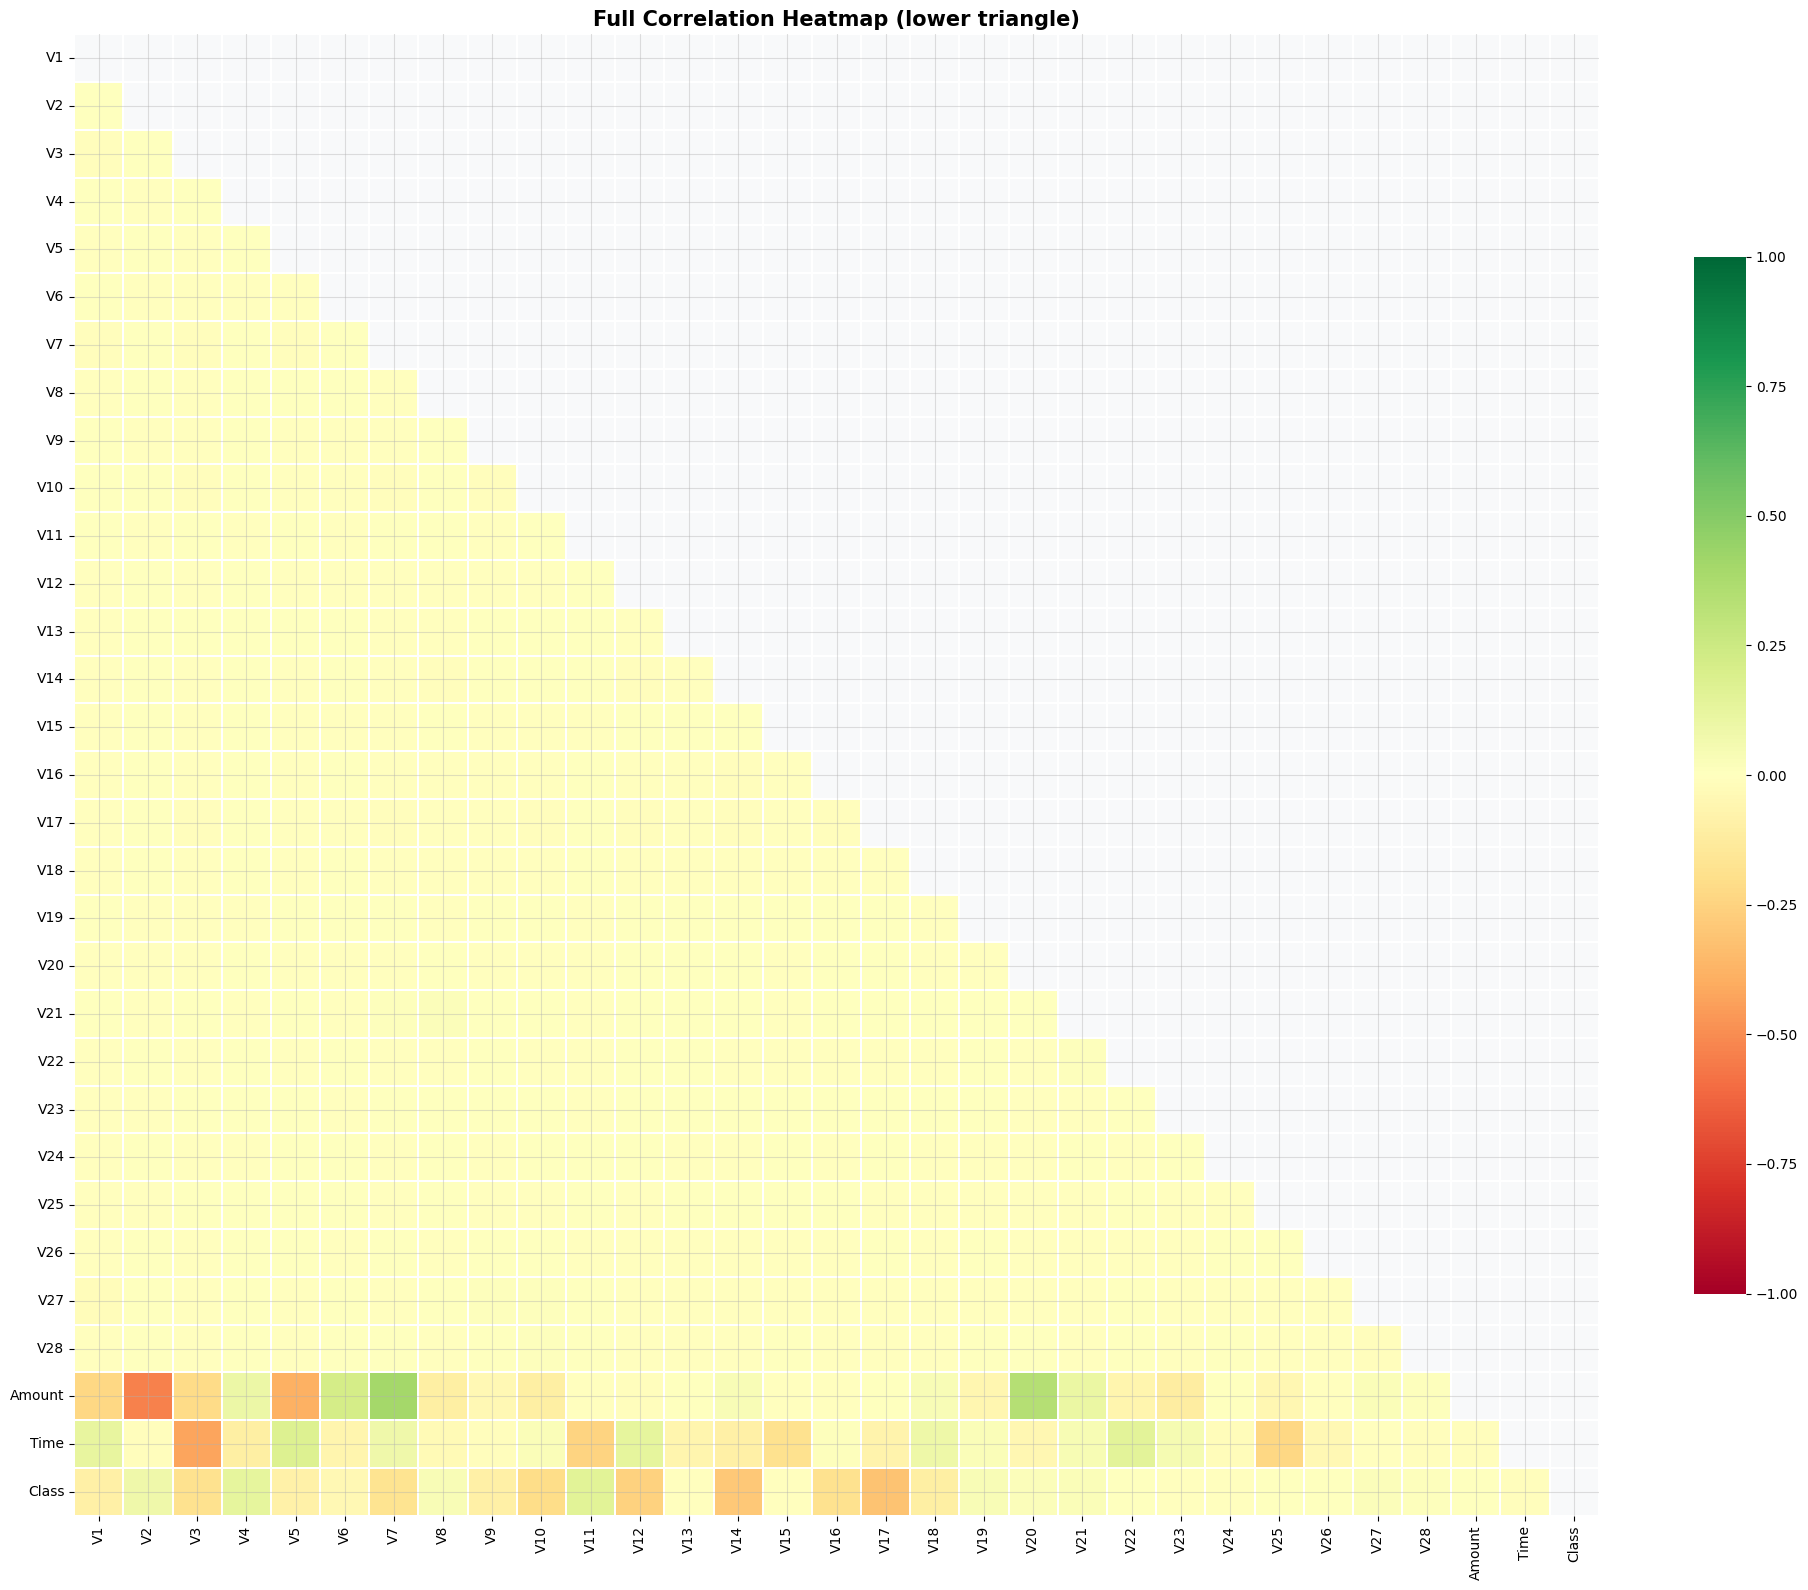

💡 V features have near-zero correlation with each other — by design.
   They are PCA components, so they are orthogonal (independent).
   This is great for models — no multicollinearity issues.


In [155]:
# ── Full correlation heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))
corr_matrix = df[v_features + ['Amount', 'Time', 'Class']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Full Correlation Heatmap (lower triangle)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 V features have near-zero correlation with each other — by design.')
print('   They are PCA components, so they are orthogonal (independent).')
print('   This is great for models — no multicollinearity issues.')

<Figure size 1400x1200 with 0 Axes>

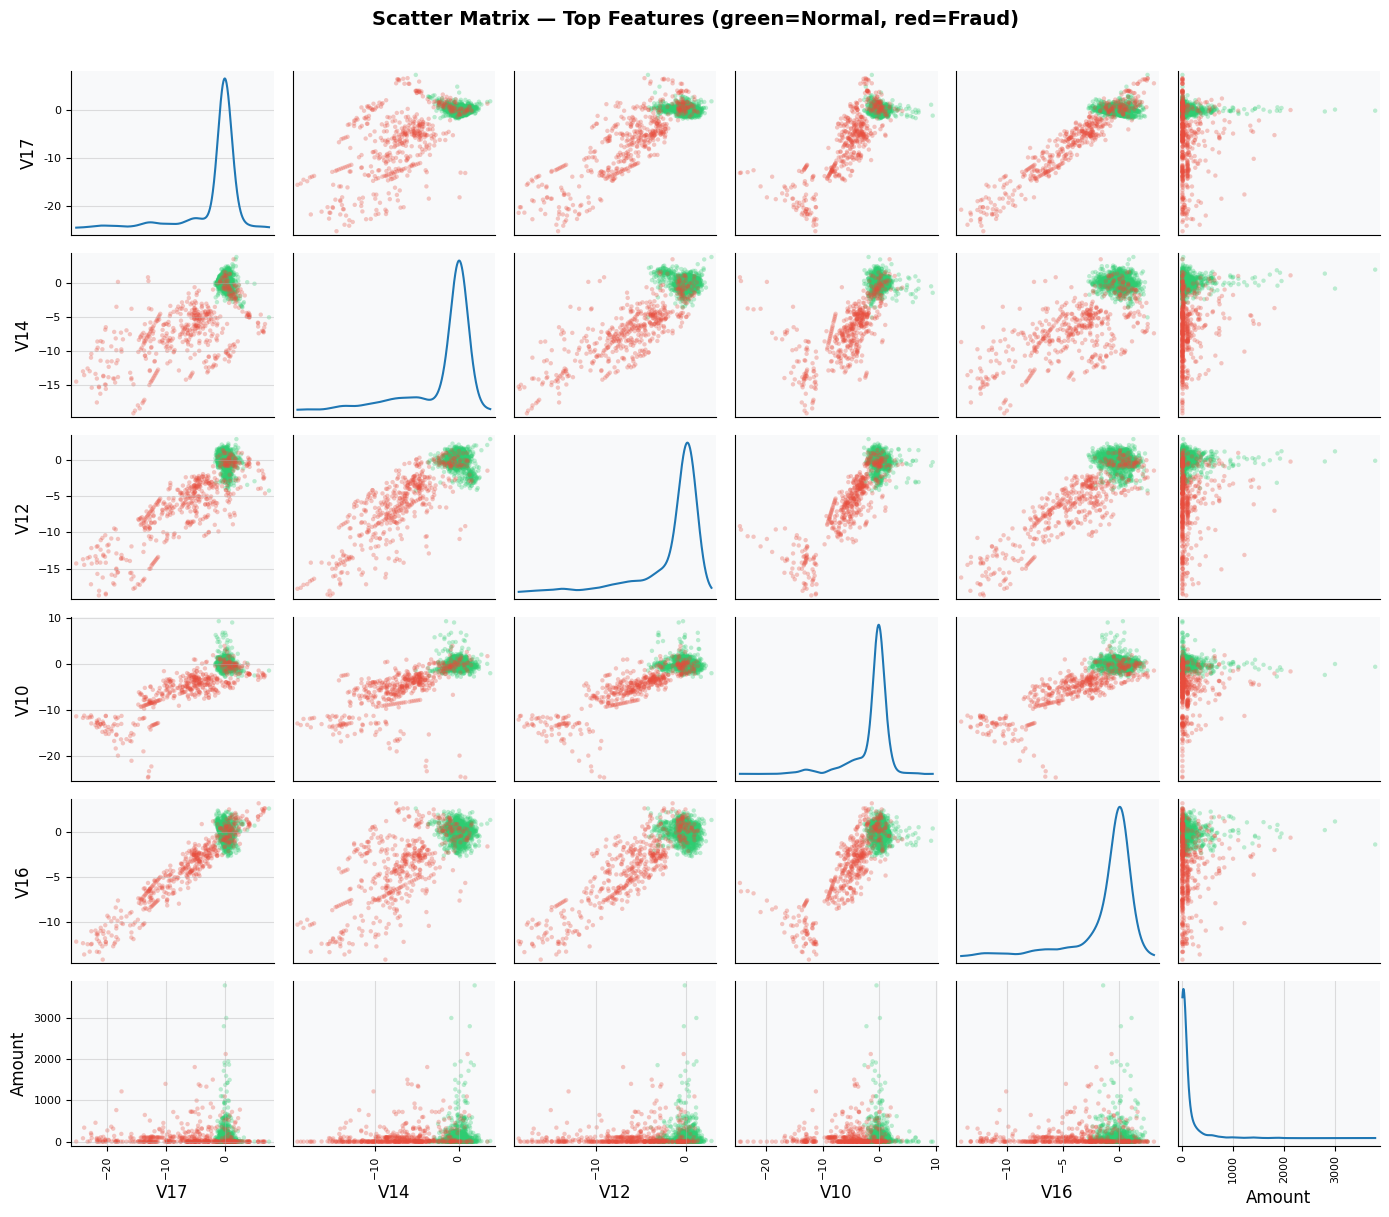

In [156]:
# ── Scatter matrix for top 6 features ────────────────────────────────────
top6 = ['V17', 'V14', 'V12', 'V10', 'V16', 'Amount']
sample_df = pd.concat([
    normal[top6 + ['Class']].sample(1500, random_state=42),
    fraud[top6 + ['Class']]
])

fig = plt.figure(figsize=(14, 12))
pd.plotting.scatter_matrix(
    sample_df[top6],
    c=sample_df['Class'].map({0: NORMAL_COLOR, 1: FRAUD_COLOR}),
    alpha=0.3, figsize=(14, 12), diagonal='kde',
    s=10, marker='o'
)
plt.suptitle('Scatter Matrix — Top Features (green=Normal, red=Fraud)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Final Summary and Key Findings

In [157]:
print('='*65)
print('  EDA COMPLETE — KEY FINDINGS SUMMARY')
print('='*65)

fraud_final  = df[df['Class']==1]
normal_final = df[df['Class']==0]

print(f'''
DATASET
  Total rows (after dedup)  : {len(df):,}
  Duplicates removed        : 1,081
  Missing values            : 0
  Features                  : 30 (V1–V28 PCA + Amount + Time)

CLASS IMBALANCE
  Normal transactions       : {len(normal_final):,} (99.8%)
  Fraud transactions        : {len(fraud_final):,} (0.17%)
  Imbalance ratio           : {len(normal_final)//len(fraud_final)}:1
  → Fix with: SMOTE + scale_pos_weight in XGBoost
  → Evaluate with: PR-AUC, Recall, F1 (NOT accuracy)

AMOUNT INSIGHTS
  Fraud median amount       : ₹{fraud_final['Amount'].median():.2f}
  Normal median amount      : ₹{normal_final['Amount'].median():.2f}
  Max fraud amount          : ₹{fraud_final['Amount'].max():,.2f}
  → Fraud happens at SMALL amounts (card testing behaviour)
  → log(1 + Amount) transformation recommended before modelling

TIME INSIGHTS
  Spans 2 days of transactions
  → Add 'Hour of day' as feature (engineered from Time)
  → Fraud rate higher during low-volume night hours

OUTLIERS
  IQR outliers (Amount)     : 31,904 rows (11.2%)
  Decision                  : KEEP all outliers
  → Fraud itself is outlier behaviour; removing outliers removes signal
  → Use log-transform to reduce skew instead

TOP PREDICTIVE FEATURES (by abs correlation with Class)
  V17, V14, V12, V10, V16, V3, V7, V11, V4, V18
  → These should appear in top XGBoost feature importances too

NEXT STEPS
  1. Feature engineering (log Amount, Hour feature)
  2. Train/test split with stratify=y
  3. Apply SMOTE on training data only
  4. StandardScaler on Amount + Time
  5. Train: Logistic Regression → Random Forest → XGBoost
  6. Evaluate with PR-AUC, F1, confusion matrix
  7. Tune classification threshold (business-driven)
  8. SHAP explainability
''')
print('='*65)

  EDA COMPLETE — KEY FINDINGS SUMMARY

DATASET
  Total rows (after dedup)  : 283,726
  Duplicates removed        : 1,081
  Missing values            : 0
  Features                  : 30 (V1–V28 PCA + Amount + Time)

CLASS IMBALANCE
  Normal transactions       : 283,253 (99.8%)
  Fraud transactions        : 473 (0.17%)
  Imbalance ratio           : 598:1
  → Fix with: SMOTE + scale_pos_weight in XGBoost
  → Evaluate with: PR-AUC, Recall, F1 (NOT accuracy)

AMOUNT INSIGHTS
  Fraud median amount       : ₹9.82
  Normal median amount      : ₹22.00
  Max fraud amount          : ₹2,125.87
  → Fraud happens at SMALL amounts (card testing behaviour)
  → log(1 + Amount) transformation recommended before modelling

TIME INSIGHTS
  Spans 2 days of transactions
  → Add 'Hour of day' as feature (engineered from Time)
  → Fraud rate higher during low-volume night hours

OUTLIERS
  IQR outliers (Amount)     : 31,904 rows (11.2%)
  Decision                  : KEEP all outliers
  → Fraud itself is outli

In [158]:
# ── Save clean dataset for next notebook ─────────────────────────────────
df.to_csv('creditcard_clean.csv', index=False)
print(f'✅ Clean dataset saved as creditcard_clean.csv')
print(f'   Shape: {df.shape}')
print(f'   Ready for preprocessing & modelling notebook.')

✅ Clean dataset saved as creditcard_clean.csv
   Shape: (283726, 32)
   Ready for preprocessing & modelling notebook.


# 12. Extra Imports

In [159]:
# ── Scikit-learn ───────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, f1_score, precision_score,
    recall_score, matthews_corrcoef, make_scorer
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

# ── Imbalanced-learn ──────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── Boosting libraries ────────────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ── SHAP ──────────────────────────────────────────────────────────────────
import shap

# ── Global plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
FRAUD_COLOR  = '#e74c3c'
NORMAL_COLOR = '#2ecc71'
ACCENT      = '#3498db'
PALETTE      = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c']

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ All libraries imported')

✅ All libraries imported


In [160]:
# Load the clean dataset saved from EDA notebook
# If creditcard_clean.csv is not available, load raw and dedup
try:
    df = pd.read_csv('creditcard_clean.csv')
    print('Loaded creditcard_clean.csv (post-EDA)')
except FileNotFoundError:
    df = pd.read_csv('creditcard.csv')
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print('Loaded raw creditcard.csv and removed duplicates')

print(f'Shape        : {df.shape}')
print(f'Fraud rows   : {df["Class"].sum():,}')
print(f'Normal rows  : {(df["Class"]==0).sum():,}')
print(f'Imbalance    : {(df["Class"]==0).sum()//df["Class"].sum()}:1')
df.head(3)

Loaded creditcard_clean.csv (post-EDA)
Shape        : (283726, 32)
Fraud rows   : 473
Normal rows  : 283,253
Imbalance    : 598:1


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0


# 13. Feature Engineering

In [161]:
# ── Engineer new features before splitting ────────────────────────────────
# Rule: feature engineering on full dataset is OK (no target leakage here)
# Scaling / SMOTE must happen AFTER the split

df['log_amount']     = np.log1p(df['Amount'])          # reduce skew
df['hour']           = (df['Time'] / 3600).astype(int) % 24  # hour of day
df['is_night']       = df['hour'].between(0, 5).astype(int)   # night flag
df['amount_sq']      = df['Amount'] ** 0.5             # sqrt transform

# Amount z-score per hour (unusual spend for that hour)
hourly_stats = df.groupby('hour')['Amount'].agg(['mean','std'])
df['amount_z_hour']  = df.apply(
    lambda r: (r['Amount'] - hourly_stats.loc[r['hour'],'mean'])
              / (hourly_stats.loc[r['hour'],'std'] + 1e-8), axis=1
)

# Drop original Time and Amount (replaced by engineered versions)
df.drop(columns=['Time', 'Amount'], inplace=True)

print('Features after engineering:')
print([c for c in df.columns if c != 'Class'])
print(f'\nTotal features : {df.shape[1]-1}')
print('\n✅ Feature engineering complete')

Features after engineering:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Hour', 'log_amount', 'hour', 'is_night', 'amount_sq', 'amount_z_hour']

Total features : 34

✅ Feature engineering complete


# 14. Train and Test Split

In [162]:
X = df.drop('Class', axis=1)
y = df['Class']

# ── Stratified split — preserves class ratio in both sets ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # CRITICAL for imbalanced data
    random_state=RANDOM_STATE
)

print('SPLIT SUMMARY')
print('─'*45)
print(f'Training set   : {len(X_train):>7,} rows')
print(f'Test set       : {len(X_test):>7,} rows')
print(f'\nTraining fraud : {y_train.sum()}')
print(f'Test fraud     : {y_test.sum()}')
print(f'\nTrain fraud %  : {y_train.mean()*100:.3f}%')
print(f'Test fraud %   : {y_test.mean()*100:.3f}%')
print('\n✅ Stratification maintained — both sets have same fraud ratio')

SPLIT SUMMARY
─────────────────────────────────────────────
Training set   : 226,980 rows
Test set       :  56,746 rows

Training fraud : 378
Test fraud     : 95

Train fraud %  : 0.167%
Test fraud %   : 0.167%

✅ Stratification maintained — both sets have same fraud ratio


# 15. Preprocessing - Scale + SMOTE

In [163]:
# ── Step 1: Scale features ─────────────────────────────────────────────────
# FIT on train only → TRANSFORM both train and test
# Never fit on test data — that's data leakage

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # only transform, no fit

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print('Scaling complete')
print(f'Mean of log_amount (train, post-scale): {X_train_scaled["log_amount"].mean():.4f}  ← should be ~0')
print(f'Std  of log_amount (train, post-scale): {X_train_scaled["log_amount"].std():.4f}   ← should be ~1')

Scaling complete
Mean of log_amount (train, post-scale): 0.0000  ← should be ~0
Std  of log_amount (train, post-scale): 1.0000   ← should be ~1


SMOTE RESAMPLING RESULTS
─────────────────────────────────────────────
Before SMOTE — train fraud   :    378
Before SMOTE — train normal  : 226602
After SMOTE  — train fraud   : 226602
After SMOTE  — train normal  : 226602
Total training rows now      : 453204

✅ Training set is now balanced 50/50
⚠️  Test set remains untouched — real distribution preserved


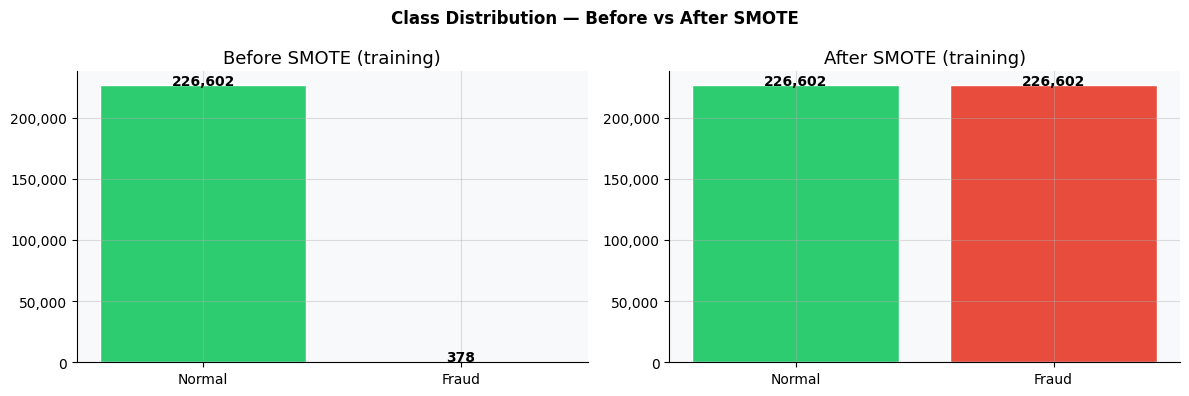

In [164]:
# ── Step 2: SMOTE — only on TRAINING data ─────────────────────────────────
# SMOTE creates synthetic minority samples by interpolating between existing ones
# NEVER apply to test data — evaluation must reflect real-world distribution

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('SMOTE RESAMPLING RESULTS')
print('─'*45)
print(f'Before SMOTE — train fraud   : {y_train.sum():>6}')
print(f'Before SMOTE — train normal  : {(y_train==0).sum():>6}')
print(f'After SMOTE  — train fraud   : {y_train_sm.sum():>6}')
print(f'After SMOTE  — train normal  : {(y_train_sm==0).sum():>6}')
print(f'Total training rows now      : {len(X_train_sm):>6}')
print()
print('✅ Training set is now balanced 50/50')
print('⚠️  Test set remains untouched — real distribution preserved')

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution — Before vs After SMOTE', fontweight='bold')
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), 'Before SMOTE (training)'),
    (pd.Series(y_train_sm).value_counts(), 'After SMOTE (training)')
]):
    ax.bar(['Normal','Fraud'], counts.sort_index().values,
           color=[NORMAL_COLOR, FRAUD_COLOR], edgecolor='white')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{int(x):,}'))
    for i, v in enumerate(counts.sort_index().values):
        ax.text(i, v+500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Training models





In [165]:
# ── Define all models ─────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', random_state=RANDOM_STATE
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5, metric='euclidean', n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=12, min_samples_leaf=5,
        n_jobs=-1, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=(y_train==0).sum()/y_train.sum(),
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='aucpr', use_label_encoder=False,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        is_unbalance=True, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
}

print(f'{len(models)} models defined — ready to train')

6 models defined — ready to train


In [166]:
# ── Train all models and collect predictions ───────────────────────────────
trained_models = {}
predictions    = {}  # {name: {y_pred, y_prob}}

for name, model in models.items():
    print(f'Training {name}...', end=' ')
    t0 = time.time()
    model.fit(X_train_sm, y_train_sm)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    trained_models[name] = model
    predictions[name] = {'y_pred': y_pred, 'y_prob': y_prob}
    print(f'done in {elapsed:.1f}s  |  Recall={recall_score(y_test,y_pred):.3f}  ROC-AUC={roc_auc_score(y_test,y_prob):.4f}')

print('\n✅ All models trained')

Training Logistic Regression... done in 3.6s  |  Recall=0.874  ROC-AUC=0.9700
Training Decision Tree... done in 38.0s  |  Recall=0.789  ROC-AUC=0.8973
Training K-Nearest Neighbors... done in 0.1s  |  Recall=0.789  ROC-AUC=0.9098
Training Random Forest... done in 408.7s  |  Recall=0.789  ROC-AUC=0.9807
Training XGBoost... done in 37.3s  |  Recall=0.821  ROC-AUC=0.9601
Training LightGBM... done in 29.8s  |  Recall=0.789  ROC-AUC=0.9715

✅ All models trained


## 17. Model Comparison

In [167]:
# ── Build comprehensive metrics table ─────────────────────────────────────
rows = []
for name, preds in predictions.items():
    yp  = preds['y_pred']
    ypr = preds['y_prob']
    rows.append({
        'Model'          : name,
        'Accuracy'       : round((yp == y_test).mean(), 4),
        'Precision'      : round(precision_score(y_test, yp, zero_division=0), 4),
        'Recall'         : round(recall_score(y_test, yp), 4),
        'F1'             : round(f1_score(y_test, yp), 4),
        'ROC-AUC'        : round(roc_auc_score(y_test, ypr), 4),
        'PR-AUC'         : round(average_precision_score(y_test, ypr), 4),
        'MCC'            : round(matthews_corrcoef(y_test, yp), 4),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')

# Highlight best in each column
print('MODEL COMPARISON — ALL METRICS')
print('(MCC = Matthews Correlation Coefficient — best single metric for imbalanced data)')
display(
    metrics_df.style
    .highlight_max(axis=0, color='#d4edda')   # green = best
    .highlight_min(axis=0, color='#f8d7da')   # red = worst
    .format('{:.4f}')
    .set_caption('Green = best per column | Red = worst per column')
)

MODEL COMPARISON — ALL METRICS
(MCC = Matthews Correlation Coefficient — best single metric for imbalanced data)


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,,
Logistic Regression,0.9732,0.0522,0.8737,0.0986,0.9700,0.6882,0.2099
Decision Tree,0.9844,0.0798,0.7895,0.1449,0.8973,0.4421,0.2480
K-Nearest Neighbors,0.9978,0.4121,0.7895,0.5415,0.9098,0.4784,0.5695
Random Forest,0.9991,0.7143,0.7895,0.7500,0.9807,0.7893,0.7505
XGBoost,0.9941,0.1965,0.8211,0.3171,0.9601,0.7857,0.4000
LightGBM,0.9988,0.6148,0.7895,0.6912,0.9715,0.7894,0.6961


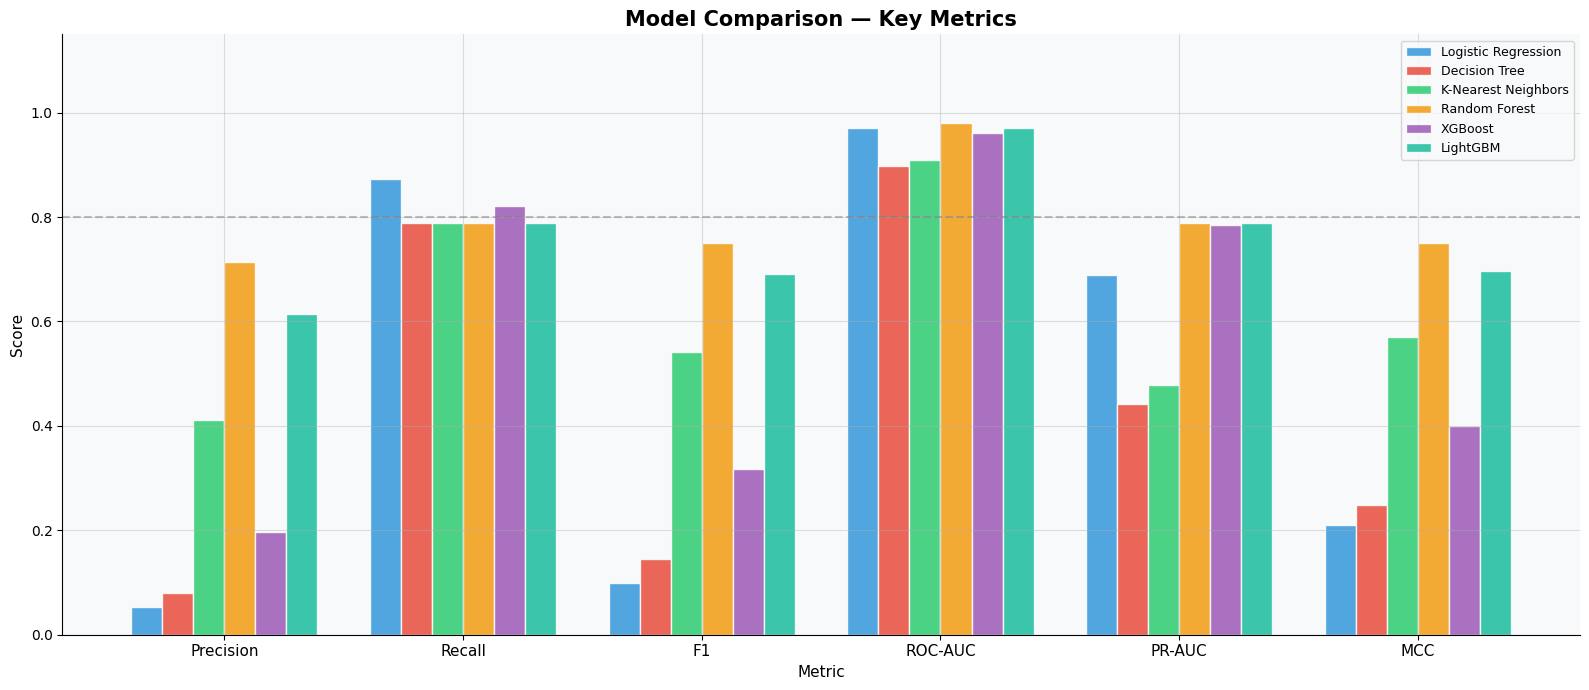

In [168]:
# ── Metric comparison radar / bar charts ──────────────────────────────────
key_metrics = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'MCC']
x = np.arange(len(key_metrics))
width = 0.13

fig, ax = plt.subplots(figsize=(16, 7))
for i, (name, row) in enumerate(metrics_df.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in key_metrics],
                  width, label=name, color=PALETTE[i], alpha=0.85, edgecolor='white')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Key Metrics', fontsize=15, fontweight='bold')
ax.set_xticks(x + width * (len(models)-1) / 2)
ax.set_xticklabels(key_metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=9)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='0.8 threshold')
plt.tight_layout()
plt.show()

## 18. Confusion Matrix

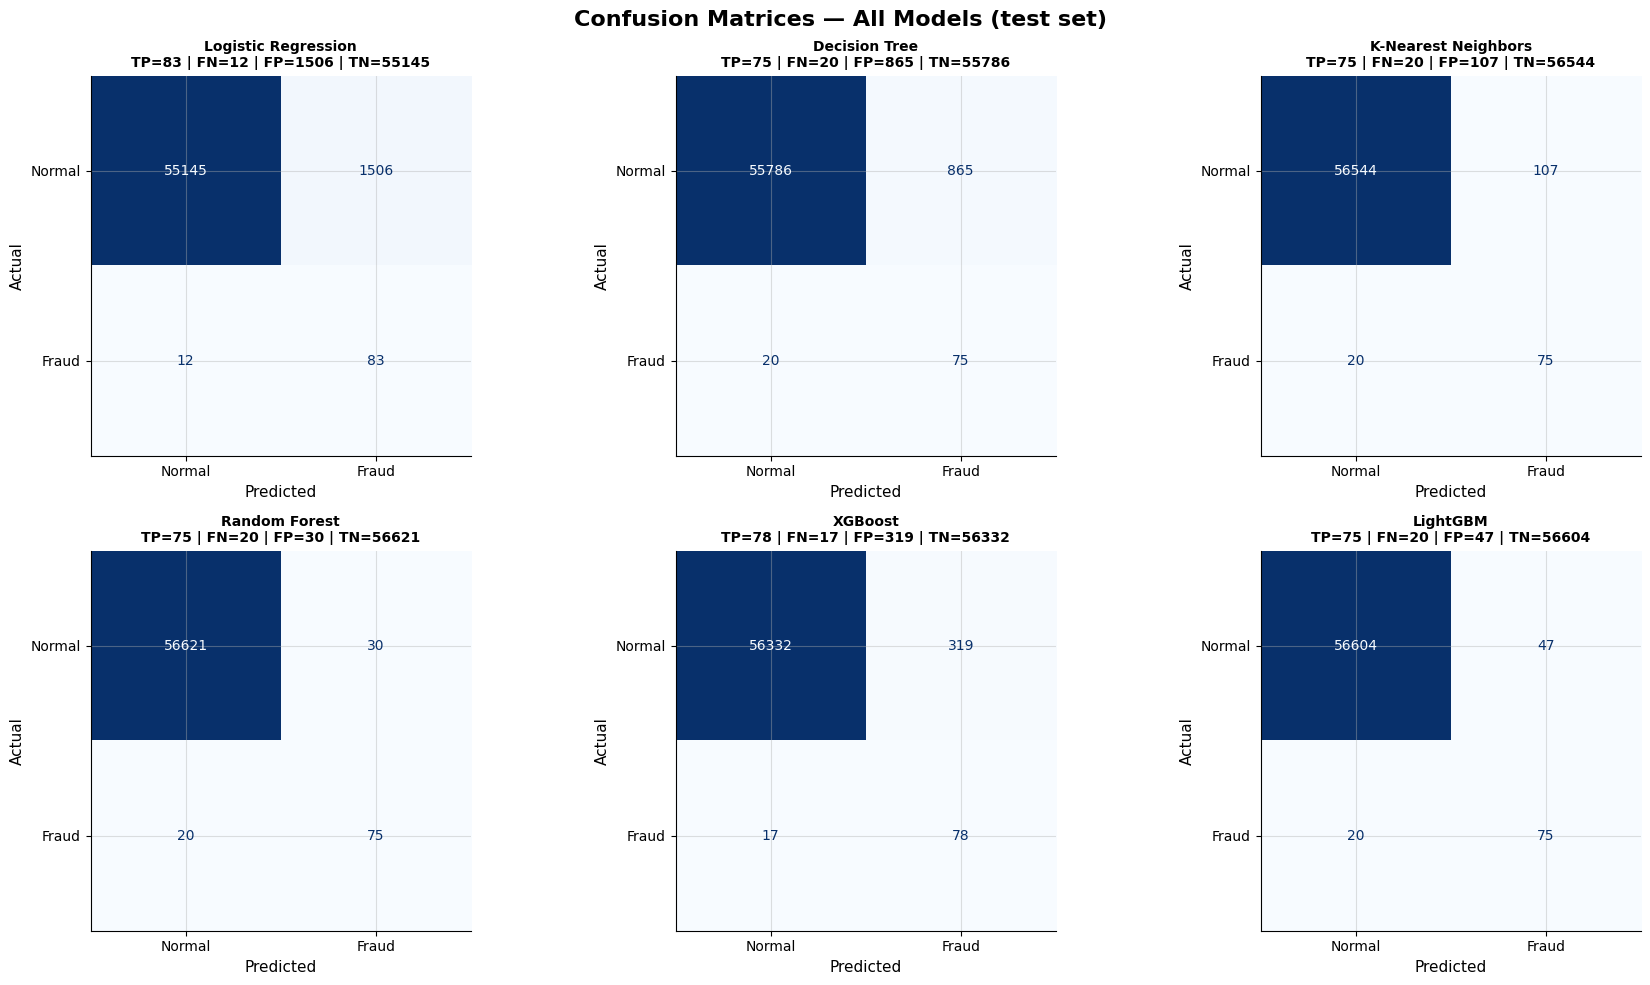


KEY: What to focus on for fraud detection
  FN (False Negatives) = actual fraud we MISSED  → minimize this
  FP (False Positives) = normal flagged as fraud → annoying but not critical
  TP (True Positives)  = fraud correctly caught  → maximize this


In [169]:
# ── Confusion matrix for every model side by side ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices — All Models (test set)',
             fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds['y_pred'])
    tn, fp, fn, tp = cm.ravel()

    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(
        f'{name}\nTP={tp} | FN={fn} | FP={fp} | TN={tn}',
        fontsize=10, fontweight='bold'
    )
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print()
print('KEY: What to focus on for fraud detection')
print('  FN (False Negatives) = actual fraud we MISSED  → minimize this')
print('  FP (False Positives) = normal flagged as fraud → annoying but not critical')
print('  TP (True Positives)  = fraud correctly caught  → maximize this')

In [170]:
# ── Detailed confusion matrix breakdown ───────────────────────────────────
print(f'{'Model':<25} {'TP':>6} {'FN':>6} {'FP':>6} {'TN':>8} {'Fraud Caught %':>15}')
print('─'*70)
for name, preds in predictions.items():
    cm = confusion_matrix(y_test, preds['y_pred'])
    tn, fp, fn, tp = cm.ravel()
    caught_pct = tp / (tp + fn) * 100
    print(f'{name:<25} {tp:>6} {fn:>6} {fp:>6} {tn:>8} {caught_pct:>14.1f}%')

Model                         TP     FN     FP       TN  Fraud Caught %
──────────────────────────────────────────────────────────────────────
Logistic Regression           83     12   1506    55145           87.4%
Decision Tree                 75     20    865    55786           78.9%
K-Nearest Neighbors           75     20    107    56544           78.9%
Random Forest                 75     20     30    56621           78.9%
XGBoost                       78     17    319    56332           82.1%
LightGBM                      75     20     47    56604           78.9%


## 19. ROC-AUC Curve

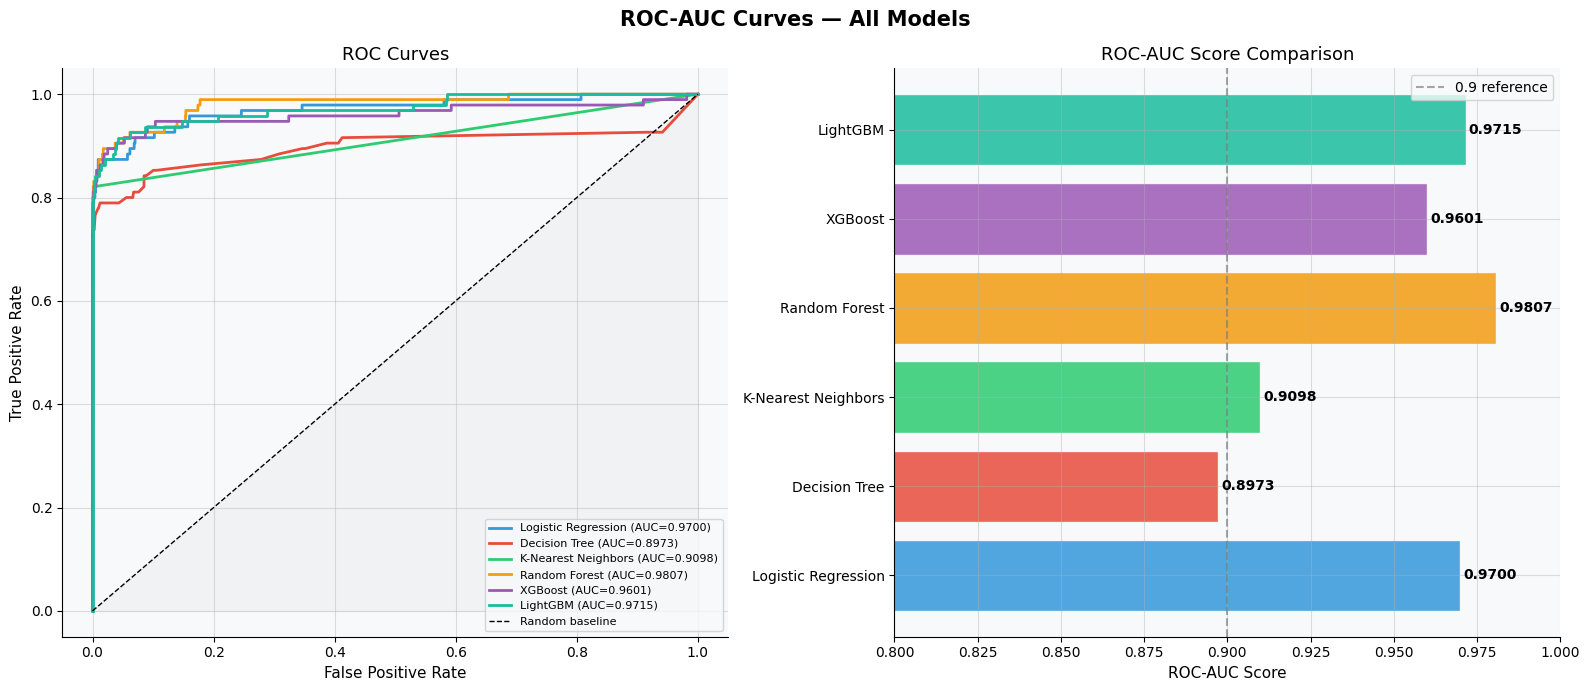

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('ROC-AUC Curves — All Models', fontsize=15, fontweight='bold')

# ── Left: Individual ROC curves ───────────────────────────────────────────
for i, (name, preds) in enumerate(predictions.items()):
    fpr, tpr, _ = roc_curve(y_test, preds['y_prob'])
    auc = roc_auc_score(y_test, preds['y_prob'])
    axes[0].plot(fpr, tpr, color=PALETTE[i], lw=2,
                 label=f'{name} (AUC={auc:.4f})')

axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random baseline')
axes[0].fill_between([0,1],[0,1], alpha=0.05, color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8, loc='lower right')

# ── Right: AUC bar chart ──────────────────────────────────────────────────
names = list(predictions.keys())
aucs  = [roc_auc_score(y_test, p['y_prob']) for p in predictions.values()]
bars  = axes[1].barh(names, aucs, color=PALETTE[:len(names)], edgecolor='white', alpha=0.85)
axes[1].set_xlim(0.8, 1.0)
axes[1].axvline(0.9, color='gray', linestyle='--', alpha=0.7, label='0.9 reference')
axes[1].set_title('ROC-AUC Score Comparison')
axes[1].set_xlabel('ROC-AUC Score')
for bar, val in zip(bars, aucs):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 20. Precision-Recall Curves

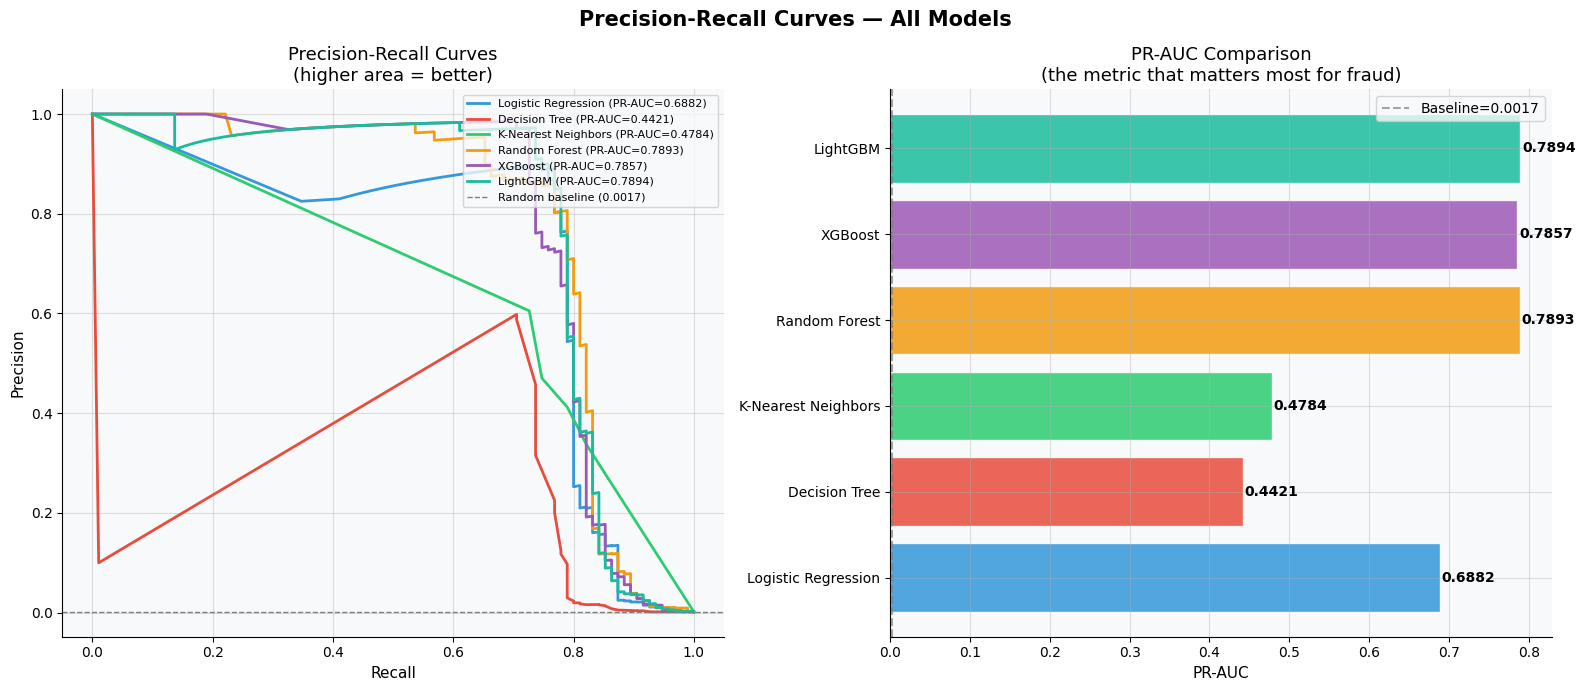


💡 The random baseline PR-AUC is only 0.0017
   Any model must MASSIVELY beat this to be useful.
   This is the metric to quote in your interview.


In [172]:
# ── PR curves are MORE informative than ROC for imbalanced data ───────────
# ROC can look great even on terrible models when classes are skewed
# PR-AUC is the gold standard for fraud detection

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Precision-Recall Curves — All Models', fontsize=15, fontweight='bold')

baseline_pr = y_test.mean()   # random classifier PR-AUC = fraud rate

for i, (name, preds) in enumerate(predictions.items()):
    prec, rec, _ = precision_recall_curve(y_test, preds['y_prob'])
    pr_auc = average_precision_score(y_test, preds['y_prob'])
    axes[0].plot(rec, prec, color=PALETTE[i], lw=2,
                 label=f'{name} (PR-AUC={pr_auc:.4f})')

axes[0].axhline(baseline_pr, color='gray', linestyle='--', lw=1,
                label=f'Random baseline ({baseline_pr:.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves\n(higher area = better)')
axes[0].legend(fontsize=8, loc='upper right')

# ── PR-AUC bar chart ──────────────────────────────────────────────────────
pr_aucs = [average_precision_score(y_test, p['y_prob']) for p in predictions.values()]
bars = axes[1].barh(list(predictions.keys()), pr_aucs,
                    color=PALETTE[:len(predictions)], edgecolor='white', alpha=0.85)
axes[1].set_xlabel('PR-AUC')
axes[1].set_title('PR-AUC Comparison\n(the metric that matters most for fraud)')
axes[1].axvline(baseline_pr, color='gray', linestyle='--', alpha=0.7,
                label=f'Baseline={baseline_pr:.4f}')
for bar, val in zip(bars, pr_aucs):
    axes[1].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\n💡 The random baseline PR-AUC is only {baseline_pr:.4f}')
print('   Any model must MASSIVELY beat this to be useful.')
print('   This is the metric to quote in your interview.')

## 21. k-fold Cross-Validation

In [173]:
# ── Stratified K-Fold — ensures each fold has the same fraud ratio ─────────
# We use the SMOTE + scaled training data for CV
# Why K-Fold? Proves the model generalises — not just lucky on one split

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scoring = {
    'f1'       : make_scorer(f1_score),
    'recall'   : make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'roc_auc'  : 'roc_auc',
}

cv_results = {}

# Run CV on top 3 models (skip KNN — too slow on 450K rows after SMOTE)
cv_models = {k: v for k, v in trained_models.items()
             if k in ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']}

for name, model in cv_models.items():
    print(f'Running 5-fold CV for {name}...', end=' ')
    t0 = time.time()
    cv = cross_validate(
        model, X_train_sm, y_train_sm,
        cv=skf, scoring=cv_scoring,
        n_jobs=-1, return_train_score=True
    )
    cv_results[name] = cv
    print(f'done in {time.time()-t0:.1f}s | '
          f'F1={cv["test_f1"].mean():.3f}±{cv["test_f1"].std():.3f} | '
          f'Recall={cv["test_recall"].mean():.3f}±{cv["test_recall"].std():.3f}')

print('\n✅ Cross-validation complete')

Running 5-fold CV for Logistic Regression... done in 14.6s | F1=0.950±0.001 | Recall=0.927±0.001
Running 5-fold CV for Random Forest... done in 1637.3s | F1=0.997±0.000 | Recall=0.994±0.000
Running 5-fold CV for XGBoost... done in 170.3s | F1=0.997±0.000 | Recall=1.000±0.000
Running 5-fold CV for LightGBM... done in 294.0s | F1=1.000±0.000 | Recall=1.000±0.000

✅ Cross-validation complete


In [174]:
# ── CV results table ──────────────────────────────────────────────────────
cv_rows = []
for name, cv in cv_results.items():
    cv_rows.append({
        'Model'            : name,
        'CV F1 (mean)'     : round(cv['test_f1'].mean(), 4),
        'CV F1 (std)'      : round(cv['test_f1'].std(), 4),
        'CV Recall (mean)' : round(cv['test_recall'].mean(), 4),
        'CV Recall (std)'  : round(cv['test_recall'].std(), 4),
        'CV ROC-AUC (mean)': round(cv['test_roc_auc'].mean(), 4),
        'Train F1 (mean)'  : round(cv['train_f1'].mean(), 4),
        'Overfit Gap'      : round(cv['train_f1'].mean() - cv['test_f1'].mean(), 4),
    })

cv_df = pd.DataFrame(cv_rows).set_index('Model')
print('5-FOLD CROSS-VALIDATION RESULTS')
print('(std = consistency across folds — lower is more stable)')
display(
    cv_df.style
    .highlight_max(subset=['CV F1 (mean)','CV Recall (mean)','CV ROC-AUC (mean)'],
                   color='#d4edda')
    .highlight_min(subset=['Overfit Gap'], color='#d4edda')
    .format('{:.4f}')
)
print()
print('Overfit Gap = Train F1 - CV F1. Higher gap = model memorising training data.')

5-FOLD CROSS-VALIDATION RESULTS
(std = consistency across folds — lower is more stable)


,CV F1 (mean),CV F1 (std),CV Recall (mean),CV Recall (std),CV ROC-AUC (mean),Train F1 (mean),Overfit Gap
Model,,,,,,,
Logistic Regression,0.9495,0.0007,0.9274,0.0008,0.9916,0.9495,-0.0000
Random Forest,0.9966,0.0002,0.9940,0.0003,1.0000,0.9971,0.0005
XGBoost,0.9968,0.0002,1.0000,0.0000,1.0000,0.9976,0.0008
LightGBM,0.9995,0.0001,1.0000,0.0000,1.0000,0.9998,0.0003



Overfit Gap = Train F1 - CV F1. Higher gap = model memorising training data.


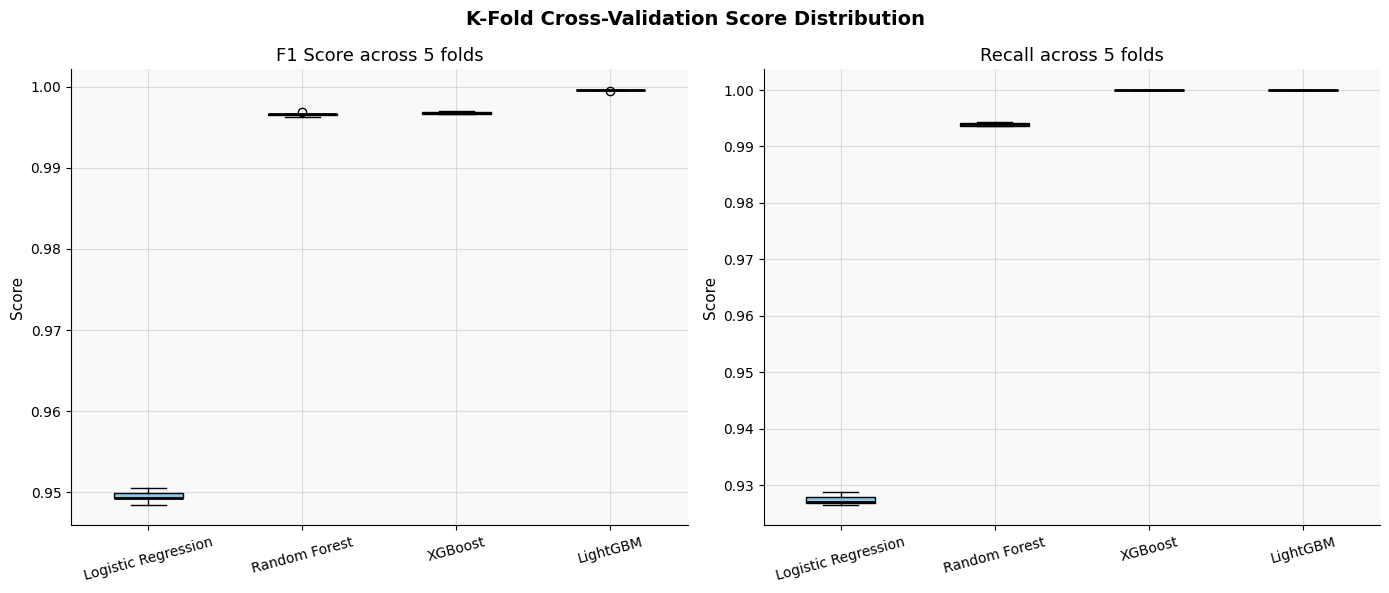

In [175]:
# ── CV score distribution — box plot per model ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('K-Fold Cross-Validation Score Distribution', fontsize=14, fontweight='bold')

for metric, ax, title in [
    ('test_f1',      axes[0], 'F1 Score across 5 folds'),
    ('test_recall',  axes[1], 'Recall across 5 folds'),
]:
    data   = [cv_results[n][metric] for n in cv_results]
    labels = list(cv_results.keys())
    bp = ax.boxplot(data, labels=labels, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color + '88')
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# 22. Learning Curve Overfitting check

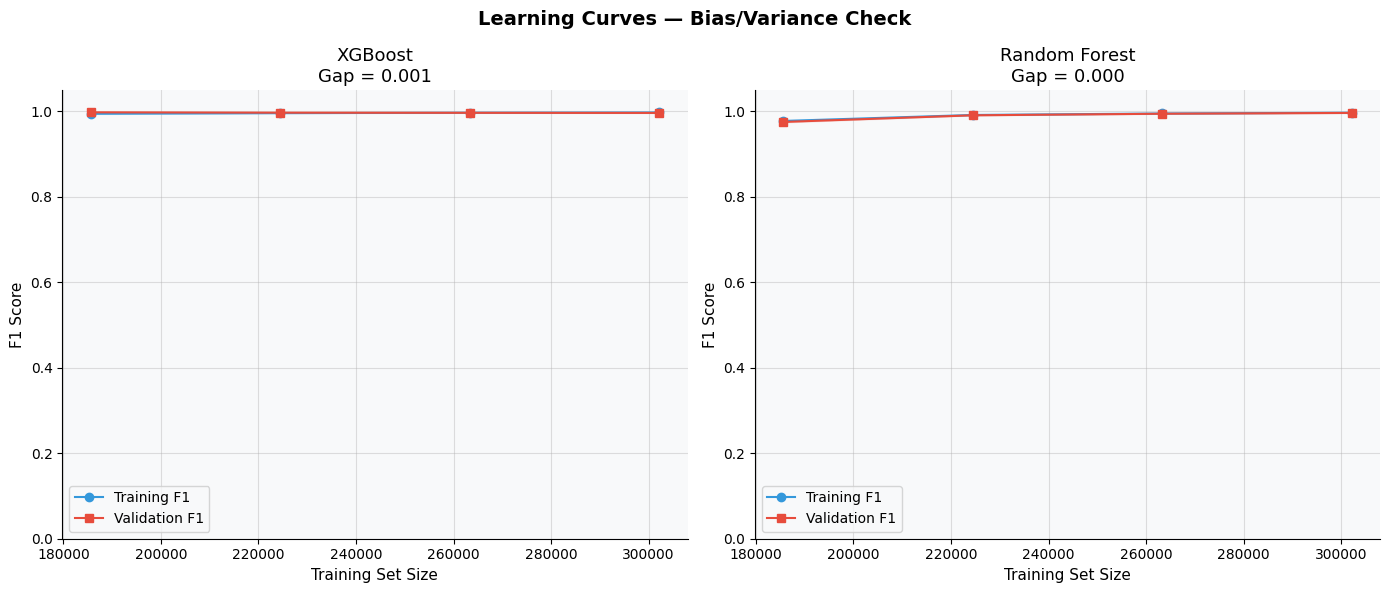

Small gap between train and val = good generalisation
Large gap = overfitting → reduce model complexity or add regularisation


In [176]:
# ── Learning curves for XGBoost and Random Forest ─────────────────────────
# Shows whether more data would help, and whether model is overfitting

lc_models = {'XGBoost': trained_models['XGBoost'],
             'Random Forest': trained_models['Random Forest']}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Learning Curves — Bias/Variance Check', fontsize=14, fontweight='bold')

train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (name, model) in zip(axes, lc_models.items()):
    sizes, train_scores, val_scores = learning_curve(
        model, X_train_sm, y_train_sm,
        train_sizes=train_sizes, cv=3,
        scoring='f1', n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    ax.plot(sizes, train_mean, 'o-', color=ACCENT, label='Training F1')
    ax.fill_between(sizes, train_mean-train_std, train_mean+train_std,
                    alpha=0.15, color=ACCENT)
    ax.plot(sizes, val_mean, 's-', color=FRAUD_COLOR, label='Validation F1')
    ax.fill_between(sizes, val_mean-val_std, val_mean+val_std,
                    alpha=0.15, color=FRAUD_COLOR)
    ax.set_title(f'{name}\nGap = {train_mean[-1]-val_mean[-1]:.3f}')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()
print('Small gap between train and val = good generalisation')
print('Large gap = overfitting → reduce model complexity or add regularisation')

## 23. Threshold Optimization

In [177]:
# ── Default threshold is 0.5 — but this is almost never optimal for fraud ──
# In fraud: missing fraud (FN) costs ~10x more than a false alarm (FP)
# We find the threshold that maximises F1, then tune for business cost

best_model_name = 'XGBoost'    # update after comparing
best_model = trained_models[best_model_name]
y_prob_best = predictions[best_model_name]['y_prob']

thresholds = np.arange(0.05, 0.95, 0.01)
results_thresh = []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    results_thresh.append({
        'threshold' : t,
        'precision' : precision_score(y_test, y_pred_t, zero_division=0),
        'recall'    : recall_score(y_test, y_pred_t),
        'f1'        : f1_score(y_test, y_pred_t),
    })

thresh_df = pd.DataFrame(results_thresh)
best_f1_thresh   = thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']
best_rec_thresh  = thresh_df.loc[thresh_df['recall'].idxmax(), 'threshold']

print(f'Default threshold (0.5):')
r50 = thresh_df[thresh_df['threshold'].round(2)==0.50].iloc[0]
print(f'  Precision={r50.precision:.3f}  Recall={r50.recall:.3f}  F1={r50.f1:.3f}')
print(f'\nBest F1 threshold = {best_f1_thresh:.2f}:')
rbf = thresh_df.loc[thresh_df['f1'].idxmax()]
print(f'  Precision={rbf.precision:.3f}  Recall={rbf.recall:.3f}  F1={rbf.f1:.3f}')

Default threshold (0.5):
  Precision=0.196  Recall=0.821  F1=0.317

Best F1 threshold = 0.94:
  Precision=0.539  Recall=0.800  F1=0.644


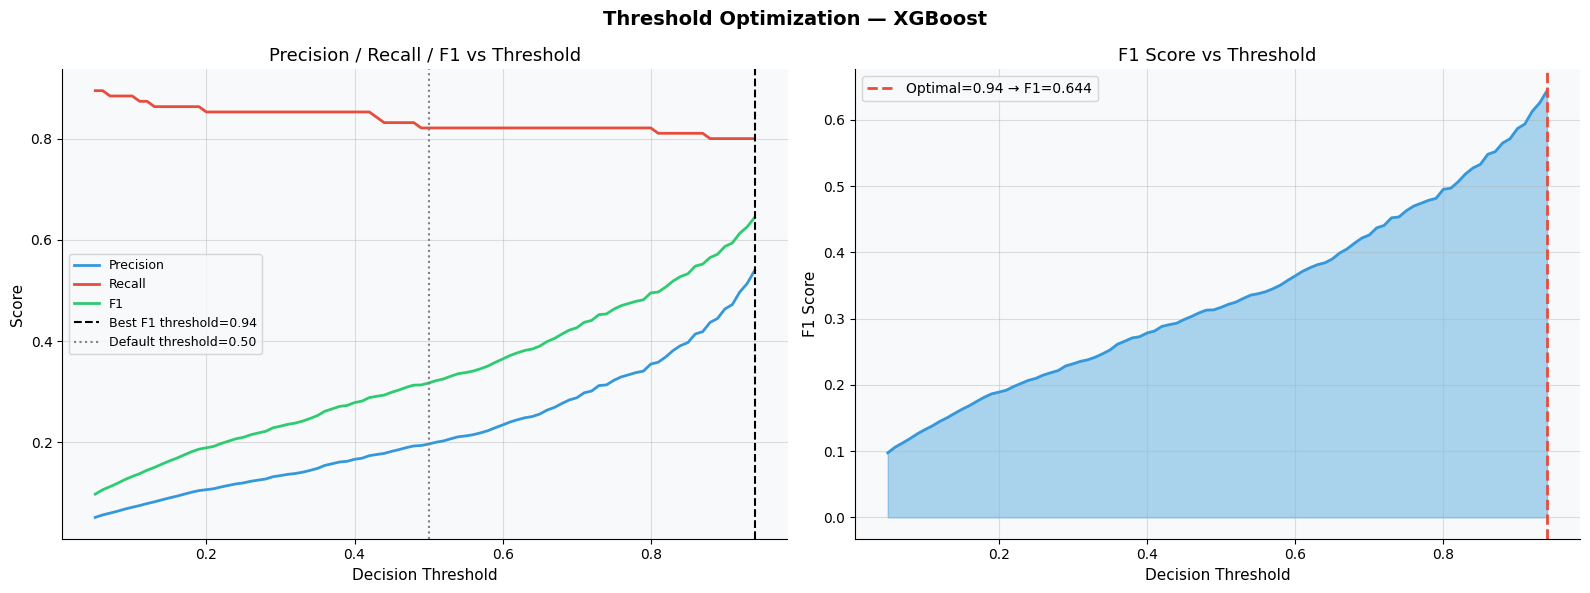


With optimal threshold (0.94):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.54      0.80      0.64        95

    accuracy                           1.00     56746
   macro avg       0.77      0.90      0.82     56746
weighted avg       1.00      1.00      1.00     56746



In [178]:
# ── Threshold visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Threshold Optimization — {best_model_name}', fontsize=14, fontweight='bold')

# Left: Precision / Recall / F1 vs threshold
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], color=ACCENT,
             lw=2, label='Precision')
axes[0].plot(thresh_df['threshold'], thresh_df['recall'],    color=FRAUD_COLOR,
             lw=2, label='Recall')
axes[0].plot(thresh_df['threshold'], thresh_df['f1'],        color=NORMAL_COLOR,
             lw=2, label='F1')
axes[0].axvline(best_f1_thresh, color='black', linestyle='--',
                label=f'Best F1 threshold={best_f1_thresh:.2f}')
axes[0].axvline(0.5, color='gray', linestyle=':',
                label='Default threshold=0.50')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].legend(fontsize=9)

# Right: F1 heatmap over threshold
axes[1].fill_between(thresh_df['threshold'], thresh_df['f1'],
                     color=ACCENT, alpha=0.4)
axes[1].plot(thresh_df['threshold'], thresh_df['f1'], color=ACCENT, lw=2)
axes[1].axvline(best_f1_thresh, color=FRAUD_COLOR, linestyle='--', lw=2,
                label=f'Optimal={best_f1_thresh:.2f} → F1={rbf.f1:.3f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

# Apply optimal threshold
y_pred_optimal = (y_prob_best >= best_f1_thresh).astype(int)
print(f'\nWith optimal threshold ({best_f1_thresh:.2f}):')
print(classification_report(y_test, y_pred_optimal, target_names=['Normal','Fraud']))

## 24. XGBoost Hyperparamter Tuning

In [179]:
# ── RandomizedSearchCV — faster than GridSearch, finds near-optimal params ─
param_dist = {
    'n_estimators'    : [200, 300, 400, 500],
    'max_depth'       : [4, 5, 6, 7, 8],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.2, 0.5],
}

xgb_base = XGBClassifier(
    scale_pos_weight=(y_train==0).sum()/y_train.sum(),
    eval_metric='aucpr', use_label_encoder=False,
    random_state=RANDOM_STATE, n_jobs=-1
)

rscv = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=30,                                          # test 30 random combos
    scoring='average_precision',                        # PR-AUC as CV metric
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, verbose=1, random_state=RANDOM_STATE
)

print('Running RandomizedSearchCV (30 iterations × 5-fold CV = 150 fits)...')
t0 = time.time()
rscv.fit(X_train_sm, y_train_sm)
print(f'Done in {time.time()-t0:.1f}s')
print(f'\nBest PR-AUC (CV): {rscv.best_score_:.4f}')
print(f'Best parameters:')
for k, v in rscv.best_params_.items():
    print(f'  {k:<25}: {v}')

Running RandomizedSearchCV (30 iterations × 5-fold CV = 150 fits)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Done in 4060.3s

Best PR-AUC (CV): 1.0000
Best parameters:
  subsample                : 0.6
  n_estimators             : 500
  min_child_weight         : 5
  max_depth                : 6
  learning_rate            : 0.1
  gamma                    : 0
  colsample_bytree         : 0.6


In [180]:
# ── Evaluate tuned model ──────────────────────────────────────────────────
xgb_tuned = rscv.best_estimator_
y_prob_tuned = xgb_tuned.predict_proba(X_test_scaled)[:, 1]
y_pred_tuned = (y_prob_tuned >= best_f1_thresh).astype(int)

print('TUNED XGBoost vs DEFAULT XGBoost')
print('─'*50)
rows_compare = []
for label, yp, ypr in [
    ('Default XGBoost', predictions['XGBoost']['y_pred'], predictions['XGBoost']['y_prob']),
    ('Tuned XGBoost',   y_pred_tuned, y_prob_tuned),
]:
    rows_compare.append({
        'Model'    : label,
        'Precision': round(precision_score(y_test, yp, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, yp), 4),
        'F1'       : round(f1_score(y_test, yp), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, ypr), 4),
        'PR-AUC'   : round(average_precision_score(y_test, ypr), 4),
        'MCC'      : round(matthews_corrcoef(y_test, yp), 4),
    })

display(pd.DataFrame(rows_compare).set_index('Model').style.highlight_max(axis=0, color='#d4edda'))

TUNED XGBoost vs DEFAULT XGBoost
──────────────────────────────────────────────────


,Precision,Recall,F1,ROC-AUC,PR-AUC,MCC
Model,,,,,,
Default XGBoost,0.196500,0.821100,0.317100,0.960100,0.785700,0.400000
Tuned XGBoost,0.863600,0.800000,0.830600,0.969600,0.814600,0.830900


# 25. Final Model Evaluation - Full Report

In [181]:
# ── Pick best model ───────────────────────────────────────────────────────
# Compare tuned XGBoost vs LightGBM — keep whichever has higher PR-AUC
lgbm_pr  = average_precision_score(y_test, predictions['LightGBM']['y_prob'])
xgb_pr   = average_precision_score(y_test, y_prob_tuned)

if xgb_pr >= lgbm_pr:
    FINAL_MODEL       = xgb_tuned
    FINAL_MODEL_NAME  = 'Tuned XGBoost'
    y_prob_final      = y_prob_tuned
else:
    FINAL_MODEL       = trained_models['LightGBM']
    FINAL_MODEL_NAME  = 'LightGBM'
    y_prob_final      = predictions['LightGBM']['y_prob']

# Recompute optimal threshold on final model
th_results = []
for t in np.arange(0.05, 0.95, 0.01):
    yp = (y_prob_final >= t).astype(int)
    th_results.append({'t': t, 'f1': f1_score(y_test, yp)})
FINAL_THRESHOLD = pd.DataFrame(th_results).loc[pd.DataFrame(th_results)['f1'].idxmax(), 't']

y_pred_final = (y_prob_final >= FINAL_THRESHOLD).astype(int)

print(f'FINAL MODEL: {FINAL_MODEL_NAME}')
print(f'THRESHOLD  : {FINAL_THRESHOLD:.2f}')
print(f'PR-AUC     : {average_precision_score(y_test, y_prob_final):.4f}')
print()
print('─'*55)
print(classification_report(y_test, y_pred_final, target_names=['Normal','Fraud']))

FINAL MODEL: Tuned XGBoost
THRESHOLD  : 0.94
PR-AUC     : 0.8146

───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56651
       Fraud       0.86      0.80      0.83        95

    accuracy                           1.00     56746
   macro avg       0.93      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746



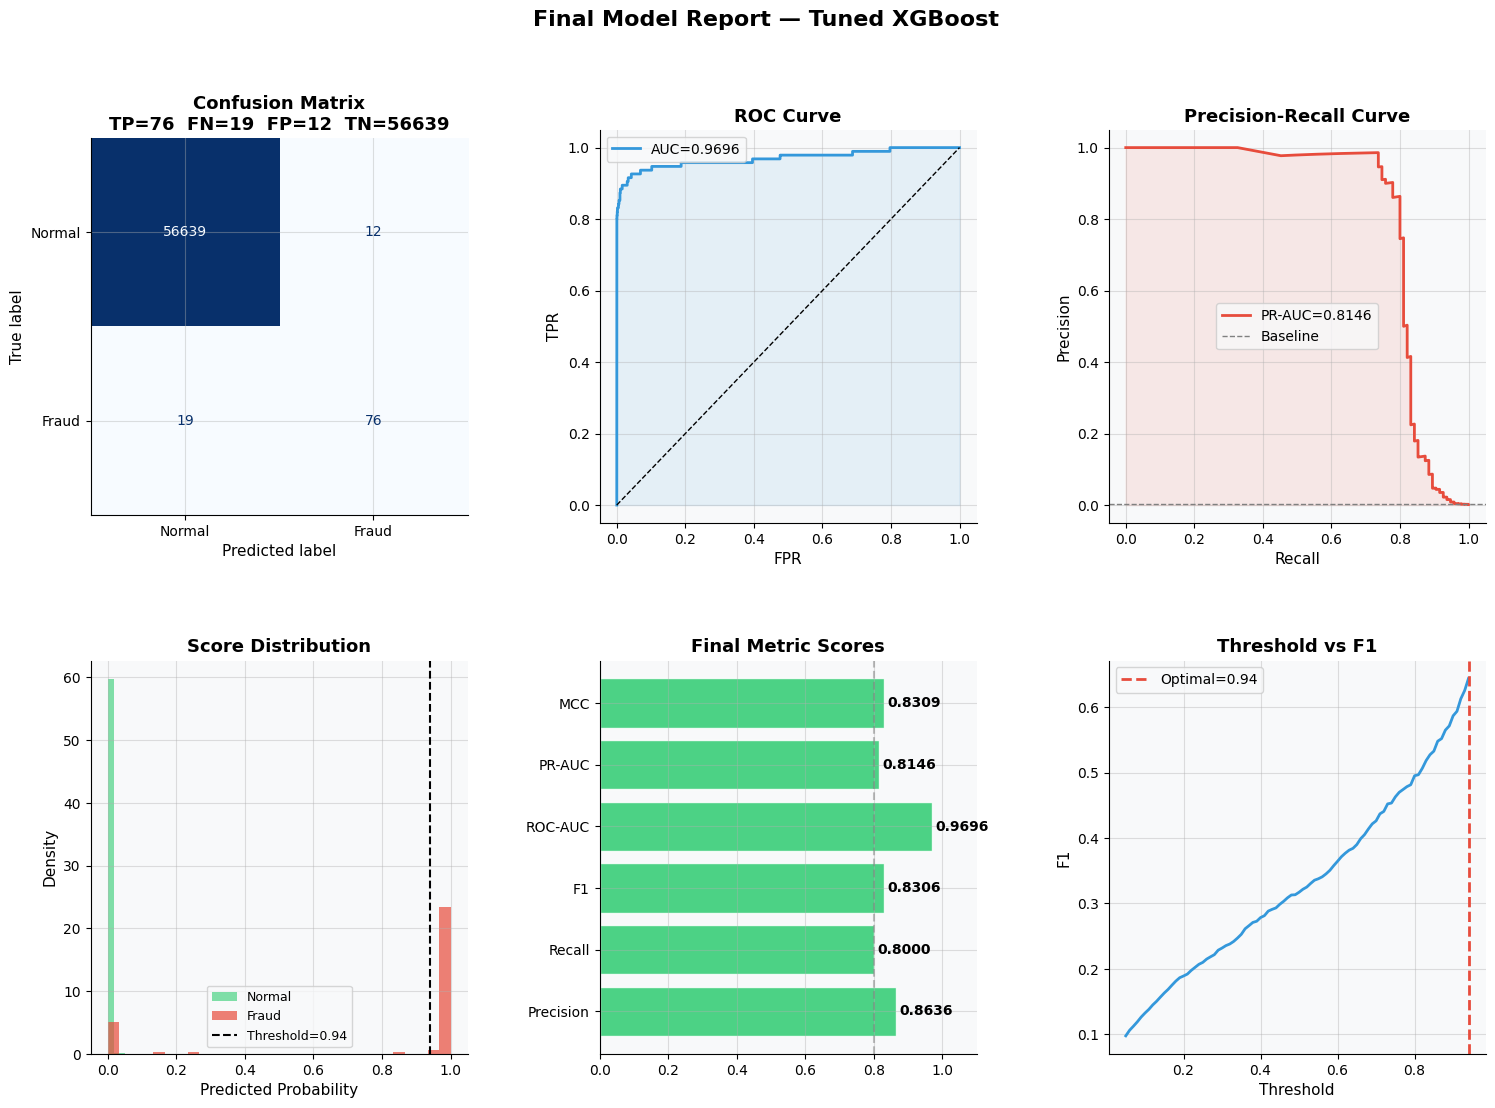


✅ Dashboard saved as final_model_report.png


In [182]:
# ── Final model — full visualization dashboard ─────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.35)
fig.suptitle(f'Final Model Report — {FINAL_MODEL_NAME}', fontsize=16, fontweight='bold')

# 1. Confusion matrix
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()
ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud']).plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title(f'Confusion Matrix\nTP={tp}  FN={fn}  FP={fp}  TN={tn}', fontweight='bold')

# 2. ROC curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
auc = roc_auc_score(y_test, y_prob_final)
ax2.plot(fpr, tpr, color=ACCENT, lw=2, label=f'AUC={auc:.4f}')
ax2.plot([0,1],[0,1],'k--',lw=1)
ax2.fill_between(fpr, tpr, alpha=0.1, color=ACCENT)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend()

# 3. PR curve
ax3 = fig.add_subplot(gs[0, 2])
prec, rec, _ = precision_recall_curve(y_test, y_prob_final)
pr_auc = average_precision_score(y_test, y_prob_final)
ax3.plot(rec, prec, color=FRAUD_COLOR, lw=2, label=f'PR-AUC={pr_auc:.4f}')
ax3.axhline(y_test.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
ax3.fill_between(rec, prec, alpha=0.1, color=FRAUD_COLOR)
ax3.set_xlabel('Recall'); ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.legend()

# 4. Probability distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(y_prob_final[y_test==0], bins=60, color=NORMAL_COLOR, alpha=0.6,
         label='Normal', density=True)
ax4.hist(y_prob_final[y_test==1], bins=30, color=FRAUD_COLOR, alpha=0.7,
         label='Fraud', density=True)
ax4.axvline(FINAL_THRESHOLD, color='black', linestyle='--',
            label=f'Threshold={FINAL_THRESHOLD:.2f}')
ax4.set_xlabel('Predicted Probability'); ax4.set_ylabel('Density')
ax4.set_title('Score Distribution', fontweight='bold')
ax4.legend(fontsize=9)

# 5. Metrics summary
ax5 = fig.add_subplot(gs[1, 1])
metric_names = ['Precision','Recall','F1','ROC-AUC','PR-AUC','MCC']
metric_vals  = [
    precision_score(y_test, y_pred_final, zero_division=0),
    recall_score(y_test, y_pred_final),
    f1_score(y_test, y_pred_final),
    roc_auc_score(y_test, y_prob_final),
    average_precision_score(y_test, y_prob_final),
    matthews_corrcoef(y_test, y_pred_final),
]
colors_bar = [NORMAL_COLOR if v>=0.8 else ACCENT if v>=0.6 else FRAUD_COLOR for v in metric_vals]
bars = ax5.barh(metric_names, metric_vals, color=colors_bar, edgecolor='white', alpha=0.85)
ax5.set_xlim(0, 1.1)
for bar, val in zip(bars, metric_vals):
    ax5.text(val+0.01, bar.get_y()+bar.get_height()/2,
             f'{val:.4f}', va='center', fontweight='bold', fontsize=10)
ax5.set_title('Final Metric Scores', fontweight='bold')
ax5.axvline(0.8, color='gray', linestyle='--', alpha=0.5)

# 6. Threshold sensitivity
ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(thresh_df['threshold'] if 'thresh_df' in dir() else [FINAL_THRESHOLD],
         thresh_df['f1'] if 'thresh_df' in dir() else [metric_vals[2]],
         color=ACCENT, lw=2)
ax6.axvline(FINAL_THRESHOLD, color=FRAUD_COLOR, linestyle='--', lw=2,
            label=f'Optimal={FINAL_THRESHOLD:.2f}')
ax6.set_xlabel('Threshold'); ax6.set_ylabel('F1')
ax6.set_title('Threshold vs F1', fontweight='bold')
ax6.legend()

plt.savefig('final_model_report.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Dashboard saved as final_model_report.png')

# 26. SHAP - Feature Importance & Explainability

In [183]:
# ── SHAP values — why did the model flag each transaction? ────────────────
print('Computing SHAP values... (takes ~30 seconds)')
explainer   = shap.TreeExplainer(FINAL_MODEL)

# Use a sample for speed (full test set can be slow)
X_shap = X_test_scaled.sample(min(2000, len(X_test_scaled)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)
print('✅ SHAP values computed')

Computing SHAP values... (takes ~30 seconds)
✅ SHAP values computed


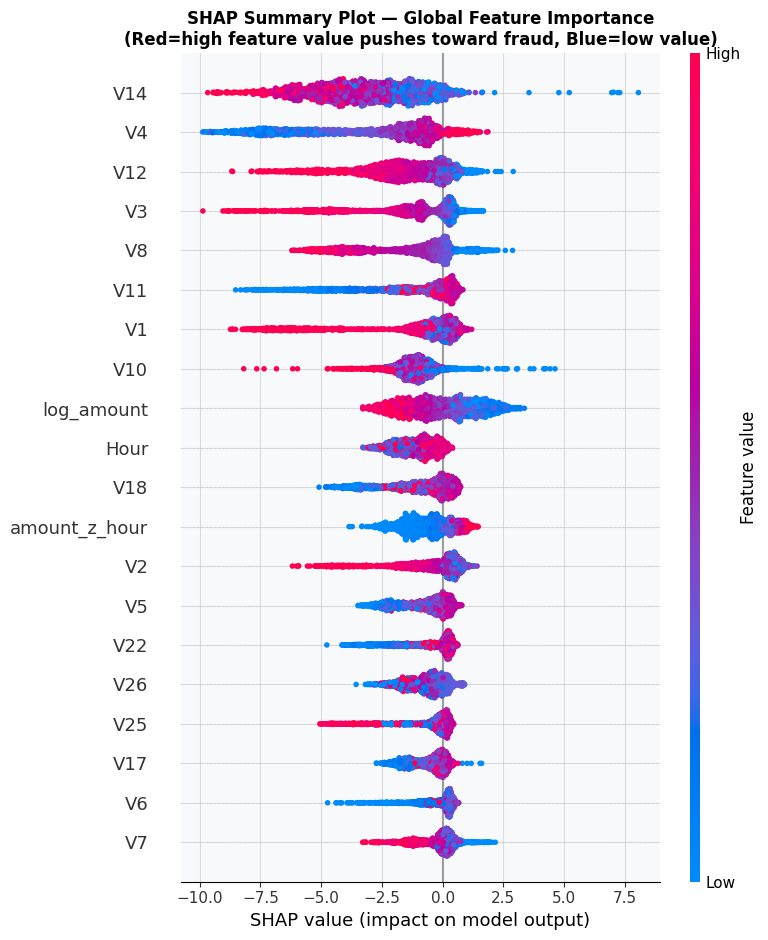

In [184]:
# ── Plot 1: Global feature importance (beeswarm) ─────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='dot', show=False,
                  max_display=20)
plt.title('SHAP Summary Plot — Global Feature Importance\n'
          '(Red=high feature value pushes toward fraud, Blue=low value)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

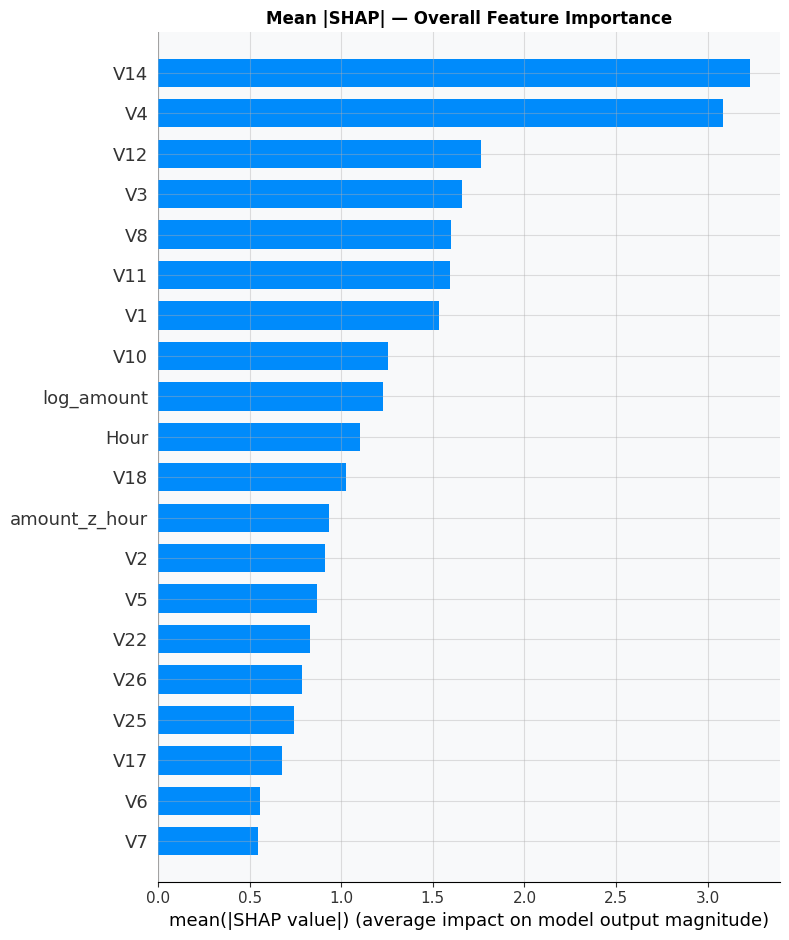

In [185]:
# ── Plot 2: Bar chart — mean absolute SHAP ────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False,
                  max_display=20)
plt.title('Mean |SHAP| — Overall Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [187]:
# # ── Plot 3: Waterfall — explain ONE specific fraud transaction ─────────────
# # Find a correctly predicted fraud transaction
# fraud_indices = X_shap.index[
#     (y_test.loc[X_shap.index] == 1) &
#     ((FINAL_MODEL.predict_proba(X_shap)[:,1] >= FINAL_THRESHOLD))
# ].tolist()

# if fraud_indices:
#     idx = fraud_indices[0]
#     shap_explanation = shap.Explanation(
#         values       = shap_values[X_shap.index.get_loc(idx)],
#         base_values  = explainer.expected_value,
#         data         = X_shap.loc[idx].values,
#         feature_names= X_shap.columns.tolist()
#     )
#     plt.figure(figsize=(12, 6))
#     shap.waterfall_plot(shap_explanation, max_display=15, show=False)
#     plt.title(f'SHAP Waterfall — Why Transaction #{idx} was flagged as Fraud',
#               fontsize=12, fontweight='bold')
#     plt.tight_layout()
#     plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
#     plt.show()
#     print('This is your KEY portfolio screenshot — shows explainability to interviewers')
# else:
#     print('No correctly-predicted fraud in sample — try increasing sample size')

<Figure size 1000x600 with 0 Axes>

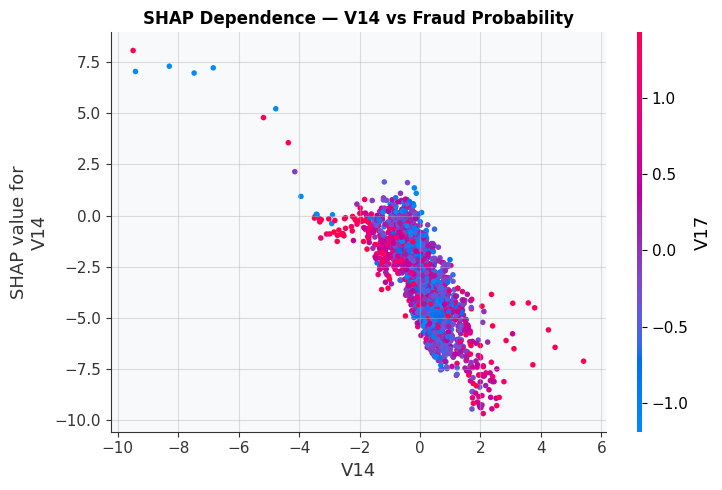

Shows how V14 value affects the fraud prediction, coloured by V17.


In [188]:
# ── Plot 4: SHAP dependence plot — how V14 affects fraud probability ───────
top_feature = 'V14'
plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values, X_shap,
                     interaction_index='V17', show=False)
plt.title(f'SHAP Dependence — {top_feature} vs Fraud Probability',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Shows how {top_feature} value affects the fraud prediction, coloured by V17.')

# Save Final Model

In [189]:
# ── Save everything needed for deployment ─────────────────────────────────
artifacts = {
    'model'          : FINAL_MODEL,
    'scaler'         : scaler,
    'threshold'      : FINAL_THRESHOLD,
    'feature_names'  : list(X.columns),
    'model_name'     : FINAL_MODEL_NAME,
    'metrics': {
        'PR-AUC'   : round(average_precision_score(y_test, y_prob_final), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob_final), 4),
        'F1'       : round(f1_score(y_test, y_pred_final), 4),
        'Recall'   : round(recall_score(y_test, y_pred_final), 4),
        'Precision': round(precision_score(y_test, y_pred_final, zero_division=0), 4),
    }
}

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('✅ Model bundle saved as fraud_model.pkl')
print(f'\nContents:')
for k in artifacts:
    print(f'  {k}')
print(f'\nFinal Performance Summary:')
for k, v in artifacts['metrics'].items():
    print(f'  {k:<12}: {v}')

✅ Model bundle saved as fraud_model.pkl

Contents:
  model
  scaler
  threshold
  feature_names
  model_name
  metrics

Final Performance Summary:
  PR-AUC      : 0.8146
  ROC-AUC     : 0.9696
  F1          : 0.8306
  Recall      : 0.8
  Precision   : 0.8636
